# Thermal analysis - Single room with double-glazed window wall
### Smart Cities - Building energy modeling | Group 7
*Aristodemou · Benito · Navarro · Guilherme*

---

The project seeks out to complete the following objectives in the context of the Smart Cities, thermal building modeling course: The .ipynb version of the file can be found on the following link:

https://github.com/stefanosaristo/building_modeling_Smart_City.git

### Objectives

- Description of the building (dimensions, materials, occupancy, etc.).
- Hypothesis (temperatures, flow rates, adiabatic walls, etc.).
- Thermal circuit.
- Values of conductances and capacities.
- Mathematical model (system of equations, matrices A, C, and G, vectors inputs b and f in time).
- Optimization of operation (night cooling, free-cooling, solar protection, non linear control, predictive control, etc.).
- Thermal load in steady-state in the most unfavorable conditions.
- Yearly energy consumption (overall consumption in kW·h and specific consumption in kW·h / m²). 

The notebook is a reproducable report containing the following:

### Contents

0. [Introduction](#0.-Introduction)
1. [Simulation Settings](#1.-Simulation-Settings)
2. [Building Geometry, Materials & Convection Coefficients](#2.-Building-Geometry,-Materials-&-Convection-Coefficients)
3. [Thermal Circuit](#3.-Thermal-Circuit)
4. [Matrix Assembly](#4.-Matrix-assembly)
5. [State-Space Representation](#5.-State-Space-Representation)
6. [Steady-State Analysis:Most Unfavourable Conditions](#6.-Steady-state-analysis:-Most-unfavourable-conditions)
7. [Yearly Energy Consumption - Steady State](#7.-Yearly-Energy-Consumption)
8. [Eigenvalue Analysis & Time Step](#8.-Eigenvalue-Analysis-&-Time-Step)
9. [Step-Response Simulation](#9.-Step-Response-Simulation)
10. [Weather Data Inputs](#10.-Simulation-with-real-weather-data-inputs)
11. [Dynamic Simulation - Real Weather](#11.-Dynamic-Simulation:-Real-Weather)

## 0. Introduction

Firstly we introduce the single-room building we study. It has 3 concrete walls, 1 double-glazed window wall, a concrete roof and a floor and door, which are not considered in the model. The architectural plan is seen below. 

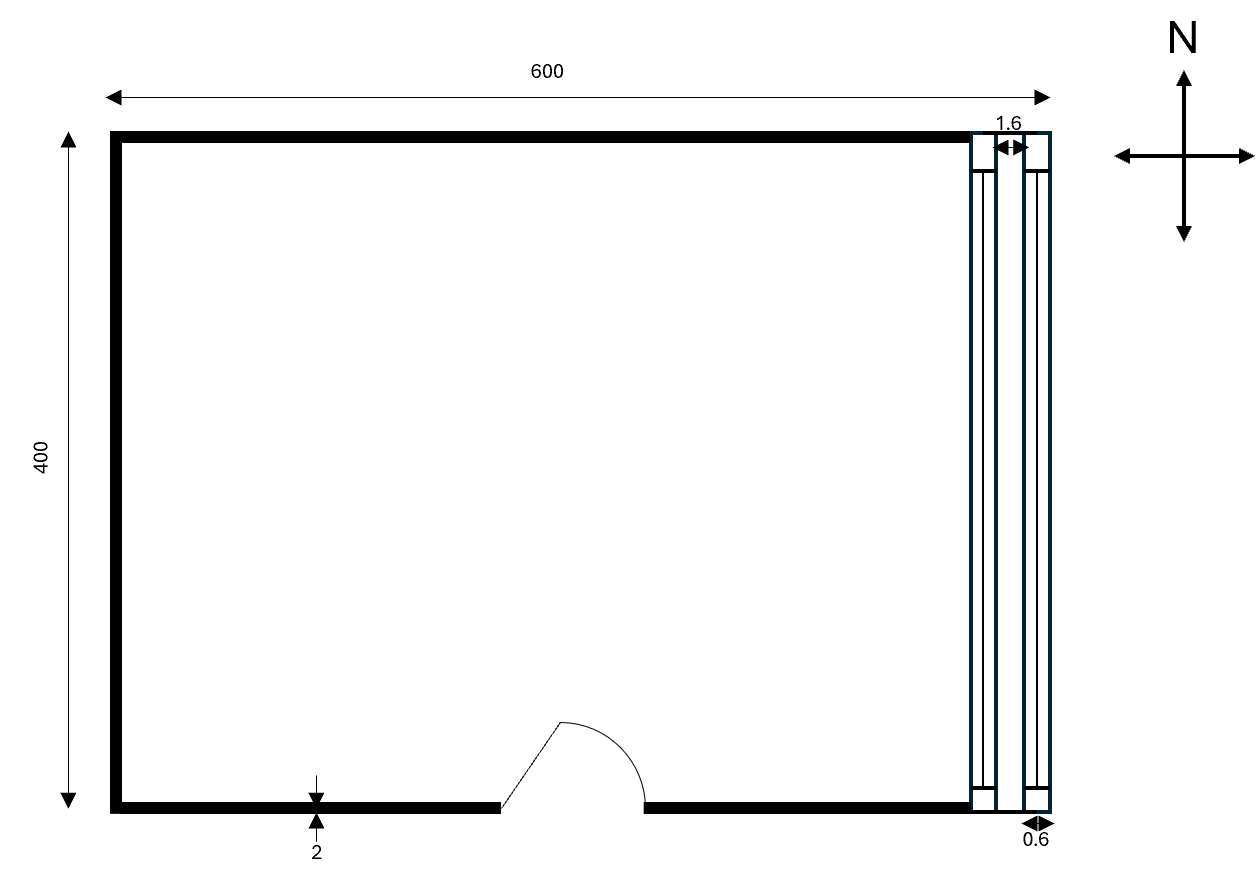

Figure 1: 2D plan of the subject building. Dimensions in cm.

The room analysed is a rectangular single-zone space with the following configuration:

Table 1: Subject room description 

| Parameter | Value |
|---|---|
| Room dimensions | 4.0 m (E–W) × 6.0 m (N–S) × 3.0 m (height) |
| Floor area | 24 m² |
| Room volume | 72 m³ |
| **Ceiling** | Concrete, horizontal, 24 m² |
| **North wall** | Concrete, vertical, 12 m² |
| **East wall** | Concrete, vertical, 18 m² |
| **West wall** | Concrete, vertical, 18 m² |
| **South wall** | Double-glazed window (glass – 16 mm air – glass), 18 m² |
| **Floor** | Adiabatic |
| Total vertical concrete area | 48 m² |

The south wall is entirely glazed and the floor is treated as adiabatic hence no branch is included in the thermal circuit for it. The modeled building has no insulation.

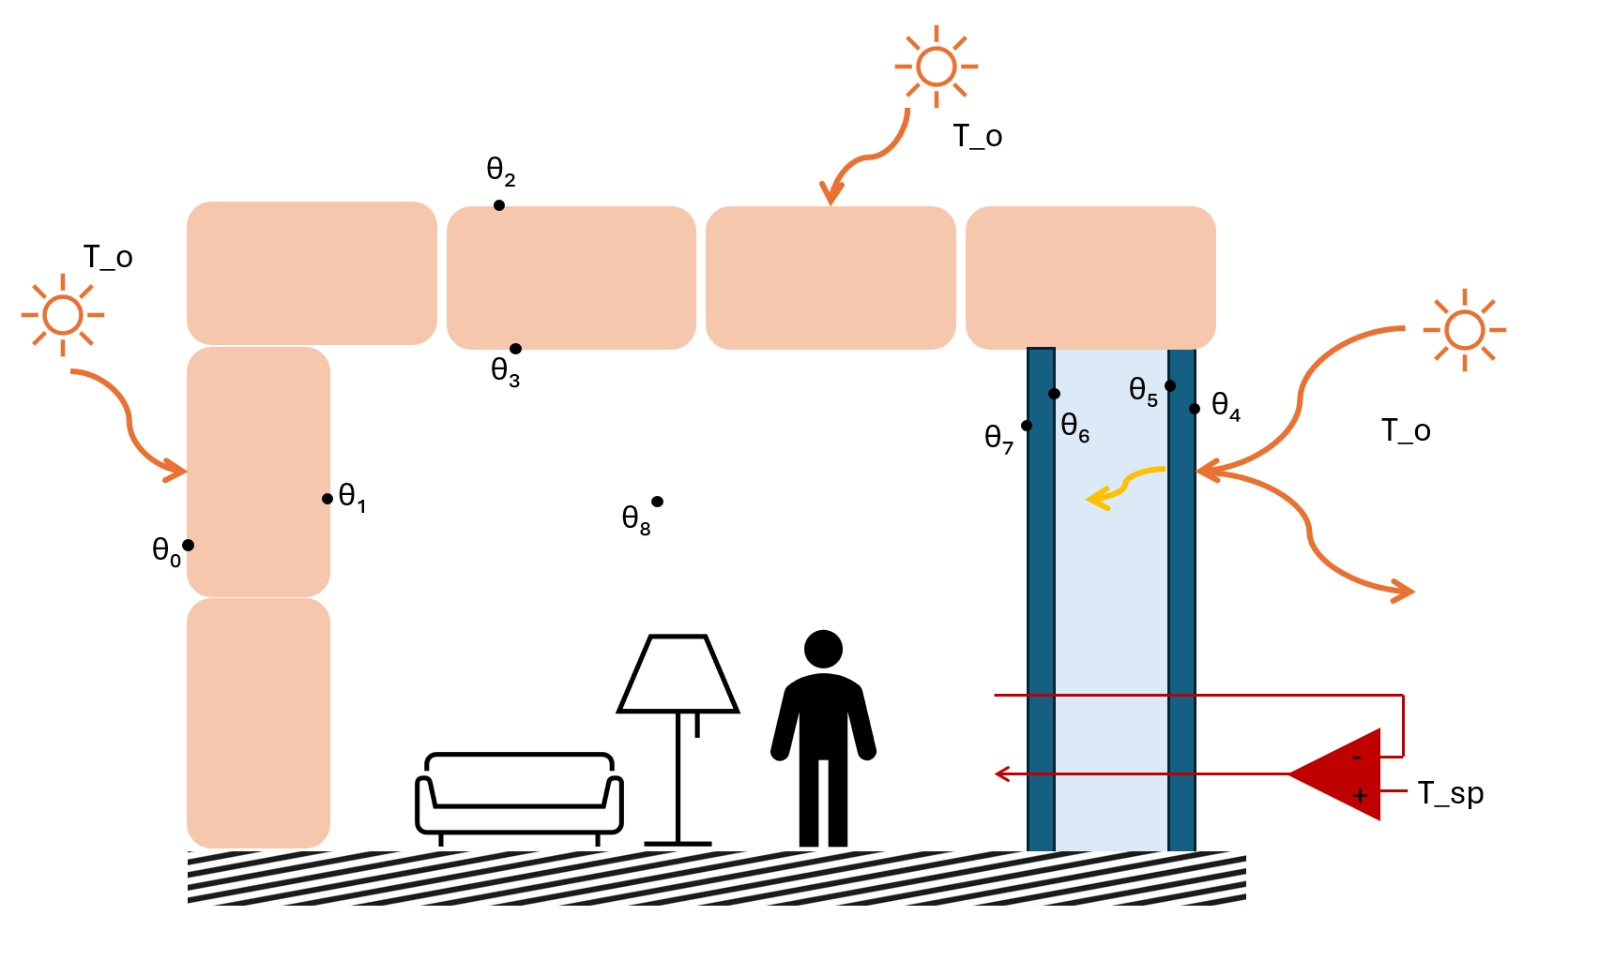

Figure 2: Front view of subject building.

The figure above, shows a front view of the structure studied. It also points out key temperature nodes and details about the proposed model explained in further detail later on in the notebook.

> **Note:** Before diving into the model structure we must consider that the following assumptions are taken into account.

### Simplifying assumptions

- The 3 vertical concrete walls are assumed to be a single element (same material, same boundary conditions).
- Heat transfer is homogeneous from one surface to another. 
- Every point of every wall has same parameters (no thermal bridges at edges or where materials change).
- The floor is adiabatic: zero heat flux at floor.
- Long-wave radiation is linearised around a mean indoor temperature T̄ = 20 °C = 293 K.
- The HVAC system is modelled as a proportional controller with gain Kp = 10⁴ W/K (approximation of a perfect controller).
- Steady-state calculation use monthly mean outdoor temperatures and solar irradiances.
- Door considered as part of the wall, not separate surface.

In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import dm4bem

warnings.filterwarnings('ignore', category=DeprecationWarning) # We used this to supress warnings due to difference in package versions between code
pd.set_option('display.float_format', '{:.3f}'.format) # taken from the course github and our installed versions.

## 1. Simulation Settings

Before building the model we fix a small set of flags and scalar parameters that control the simulation. These choices are further explained throughout the notebook:

Table 2: Preliminary simulation setting initialization

| Flag | Effect when `True` |
|---|---|
| `neglect_air_capacity` | Sets $C$ = 0 for all glass/air nodes → algebraic system, larger $\Delta t_{\max}$ |
| `neglect_controller` | Sets $G_{12} = K_p = 0$ → free-floating building |
| `imposed_time_step` | Uses the user-specified $\Delta t$ instead of the eigenvalue-derived maximum |

In [117]:
# ── Simulation flags ──────────────────────────────────────────────────────
neglect_air_capacity = True  # neglect capacities of glass panes and air gap
neglect_controller   = False  # keep HVAC proportional controller active
imposed_time_step    = True   # override eigenvalue-based time step
Δt = 1000                     #  set time step

# ── Boundary conditions ───────────────────────────────────────────────────
T_sp  = 20.0   # °C, heating set-point (winter)
T_sp_c  = 26.0   # °C, cooling set-point (summer)
To    =  0.0   # °C, outdoor temperature (worst-case scenario - winter)
ACH   =  2.0   # h⁻¹, air infiltration
Q_int =  0.0   # W,  internal gains)

print(f"neglect_air_capacity : {neglect_air_capacity}")
print(f"neglect_controller   : {neglect_controller}")
print(f"imposed_time_step    : {imposed_time_step}  →  Δt = {Δt} s")
print(f"Heating set-point    : T_sp = {T_sp} °C")
print(f"Outdoor temperature  : T_o  = {To} °C")
print(f"Air change rate      : ACH  = {ACH} h⁻¹")

neglect_air_capacity : True
neglect_controller   : False
imposed_time_step    : True  →  Δt = 1000 s
Heating set-point    : T_sp = 20.0 °C
Outdoor temperature  : T_o  = 0.0 °C
Air change rate      : ACH  = 2.0 h⁻¹


## 2. Building Geometry, Materials & Convection Coefficients

### 2.1 Room description

The room desribed in the introduction is coded in as shown: 

Table 3: Room wall naming convention

| Surface | Construction | Area |
|---|---|---|
| North wall | Concrete | $S_N = l_x \cdot h$ |
| East wall | Concrete | $S_E = l_y \cdot h$ |
| West wall | Concrete | $S_W = l_y \cdot h$ |
| Ceiling | Concrete (horizontal) | $S_{cl} = l_x \cdot l_y$ |
| South wall | Double-glazed window | $S_w = l_y \cdot h$ |
| Floor | **Adiabatic** | — |

The three vertical concrete walls are lumped into one element (same material, same boundary conditions, same heat-flow direction), giving a total vertical concrete area:
$$S_{cv} = S_N + S_E + S_W$$

### 2.2 Thermophysical properties

All properties of the materials used and displayed in the section, where taken either from the [Toy model house](https://cghiaus.github.io/dm4bem_book/tutorials/02_2_0Toy.html) example studied in class or from the [Engineering Toolbox](https://www.engineeringtoolbox.com/air-properties-viscosity-conductivity-heat-capacity-d_1509.html).

Table 4: Thermophysical properties

| Material | $\lambda$ [W/(m·K)] | $\rho$ [kg/m³] | $c_p$ [J/(kg·K)] | $e$ [m] |
|---|---|---|---|---|
| Concrete | 1.40 | 2300 | 880 | 0.20 |
| Glass pane | 1.00 | 2500 | 750 | 0.006 |
| Air gap | 0.026 | 1.2 | 1000 | 0.016 |
| Indoor air | — | 1.2 | 1000 | — |

### 2.3 Radiative and optical properties

Table 5: Radiative and optical properties

| Property | Symbol | Value |
|---|---|---|
| LW emissivity — concrete | $\varepsilon_w$ | 0.85 |
| LW emissivity — glass | $\varepsilon_g$ | 0.90 |
| SW absorptivity — concrete | $\alpha_w$ | 0.25 |
| SW absorptivity — glass pane | $\alpha_g$ | 0.38 |
| SW transmittance — each pane | $\tau_g$ | 0.30 |
| Stefan–Boltzmann constant | $\sigma$ | $5.67\times10^{-8}$ W/(m²·K⁴) |

The effective double-glazing transmittance is $\tau_{dg} = \tau_g^2$.

### 2.4 Surface convection coefficients

Table 6: Convection coefficients

| Location | Direction | $h$ [W/(m²·K)] |
|---|---|---|
| Indoor — vertical | horizontal heat flow | 8.0 |
| Indoor — ceiling | downward heat flow | 8.0 |
| Outdoor — all surfaces | wind-driven | 25.0 |

In [118]:
# ── Room geometry ─────────────────────────────────────────────────────────
l_x = 4.0   # m, width  (E–W)
l_y = 6.0   # m, length (N–S)
h   = 3.0   # m, height

S_N  = l_x * h        # m², North wall   (concrete)
S_E  = l_y * h        # m², East wall    (concrete)
S_W  = l_y * h        # m², West wall    (concrete)
S_cl = l_x * l_y      # m², Ceiling      (concrete, horizontal)
S_w  = l_y * h        # m², South wall   (double-glazed window)
S_fl = l_x * l_y      # m², Floor        (ADIABATIC — not modelled)
S_cv = S_N + S_E + S_W  # m², total lumped vertical concrete walls

print("── Surface areas ────────────────────────────")
print(f"  S_N  (North wall)      = {S_N:.1f} m²")
print(f"  S_E  (East wall)       = {S_E:.1f} m²")
print(f"  S_W  (West wall)       = {S_W:.1f} m²")
print(f"  S_cv (Total vert. conc)= {S_cv:.1f} m²")
print(f"  S_cl (Ceiling)         = {S_cl:.1f} m²")
print(f"  S_w  (Window wall)     = {S_w:.1f} m²")
print(f"  Volume Va              = {l_x*l_y*h:.1f} m³")

── Surface areas ────────────────────────────
  S_N  (North wall)      = 12.0 m²
  S_E  (East wall)       = 18.0 m²
  S_W  (West wall)       = 18.0 m²
  S_cv (Total vert. conc)= 48.0 m²
  S_cl (Ceiling)         = 24.0 m²
  S_w  (Window wall)     = 18.0 m²
  Volume Va              = 72.0 m³


In [119]:
# ── Air properties ────────────────────────────────────────────────────────
rho_a = 1.2      # kg/m³
c_a   = 1000.0   # J/(kg·K)

# ── Concrete ──────────────────────────────────────────────────────────────
lam_c = 1.40     # W/(m·K)
rho_c = 2300.0   # kg/m³
c_c   = 880.0    # J/(kg·K)
e_c   = 0.20     # m

# ── Glass pane (6 mm) ─────────────────────────────────────────────────────
lam_g = 1.00     # W/(m·K)
rho_g = 2500.0   # kg/m³
c_g   = 750.0    # J/(kg·K)
e_g   = 0.006    # m

# ── Air gap (16 mm) — effective conduction for natural convection in gap ──
lam_ag = 0.026   # W/(m·K)
e_ag   = 0.016   # m

# ── Radiative / optical properties ───────────────────────────────────────
sigma      = 5.67e-8   # W/(m²·K⁴)
eps_w      = 0.85      # LW emissivity — concrete
eps_g      = 0.90      # LW emissivity — glass
alpha_w    = 0.25      # SW absorptivity — concrete
alpha_g    = 0.38      # SW absorptivity — glass pane
tau_g_pane = 0.30      # SW transmittance — each glass pane
tau_dg     = tau_g_pane**2   # effective DG transmittance

# ── Surface convection coefficients [W/(m²·K)] ───────────────────────────
h_in_v = 8.0    # indoor, vertical surfaces
h_in_h = 8.0    # indoor, ceiling
h_out  = 25.0   # outdoor, all surfaces

print(f"Concrete  : λ={lam_c}, ρ={rho_c}, cp={c_c}, e={e_c} m")
print(f"Glass     : λ={lam_g}, ρ={rho_g}, cp={c_g}, e={e_g} m")
print(f"Air gap   : λ={lam_ag}, e={e_ag} m")
print(f"τ_dg      = {tau_dg:.4f}  (double-glazing effective transmittance)")
print(f"h_in_v = {h_in_v}, h_in_h = {h_in_h}, h_out = {h_out}  W/(m²·K)")

Concrete  : λ=1.4, ρ=2300.0, cp=880.0, e=0.2 m
Glass     : λ=1.0, ρ=2500.0, cp=750.0, e=0.006 m
Air gap   : λ=0.026, e=0.016 m
τ_dg      = 0.0900  (double-glazing effective transmittance)
h_in_v = 8.0, h_in_h = 8.0, h_out = 25.0  W/(m²·K)


## 3. Thermal Circuit

The studied room is modelled as a thermal circuit shown in figure 3. Notice the correlation of nodes between the circuit and figure 2.

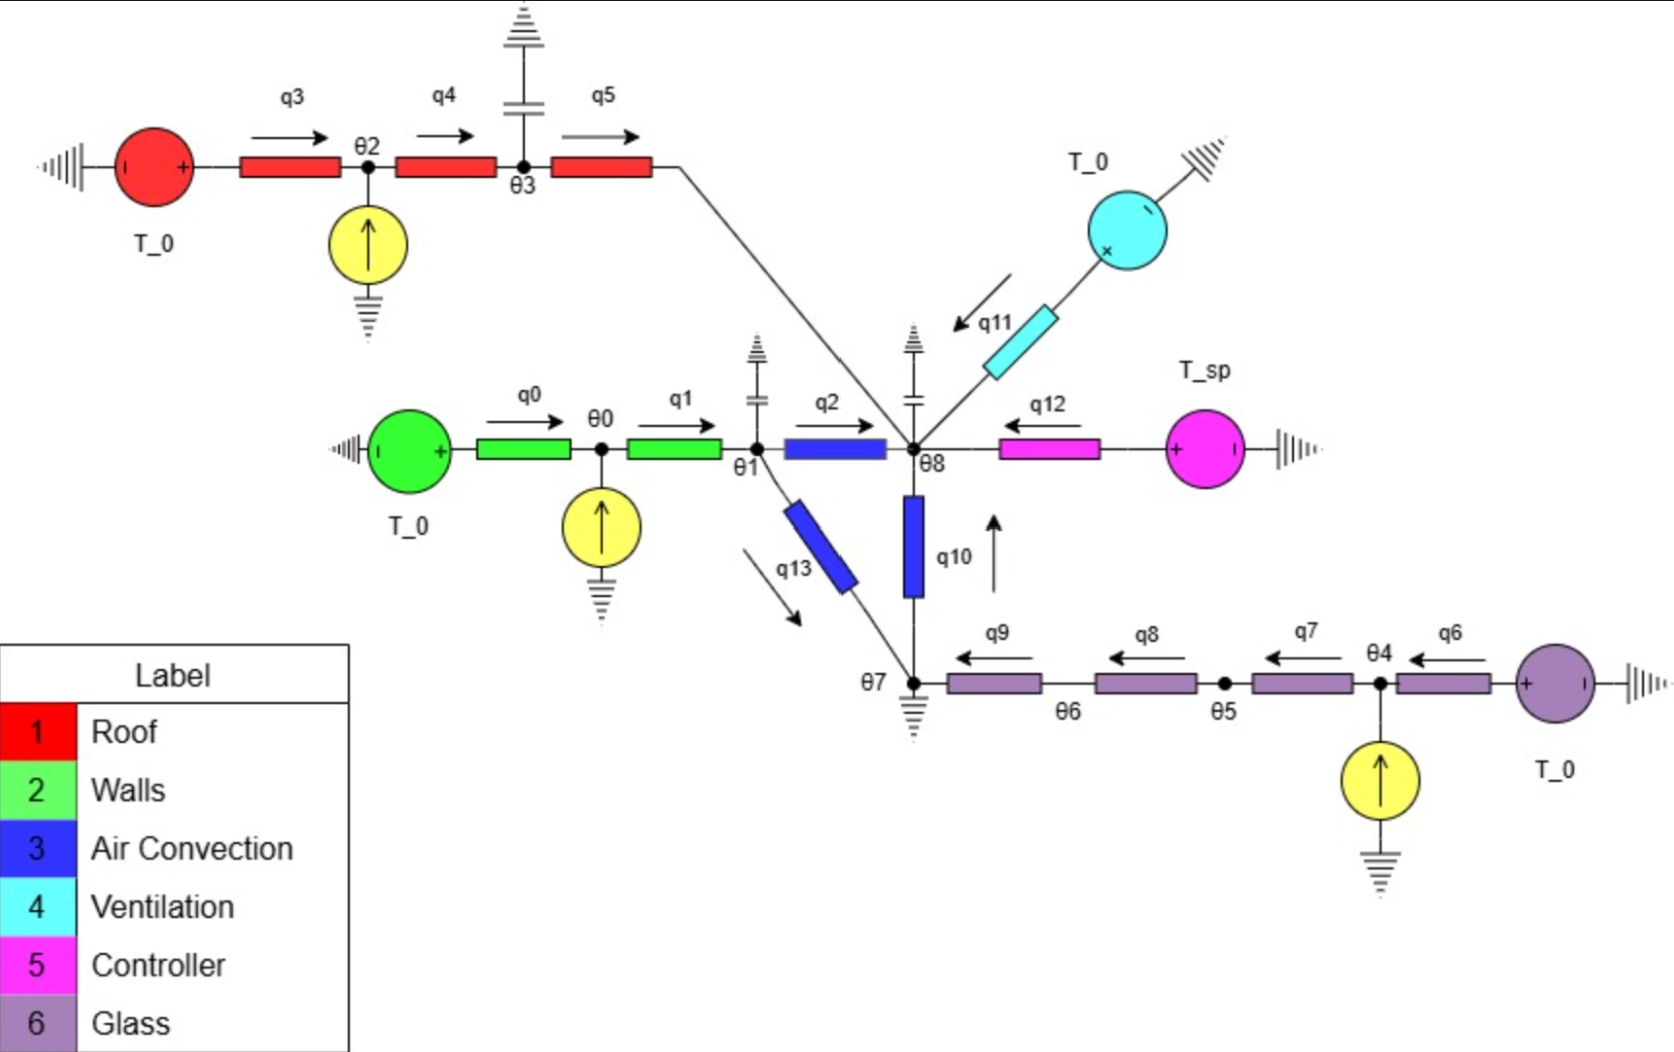

Figure 3: Thermal circuit

The thermal network contains **9 temperature nodes** ($\theta_0 \ldots \theta_8$) and **14 branches** ($q_0 \ldots q_{13}$):

### Node map

Table 7: Temperature node map - desciption

| Node | Location |
|---|---|
| $\theta_0$ | Outer surface, vertical concrete walls (lumped) |
| $\theta_1$ | Inner surface, vertical concrete walls |
| $\theta_2$ | Outer surface, concrete ceiling |
| $\theta_3$ | Inner surface, concrete ceiling |
| $\theta_4$ | Outdoor face, outer glass pane |
| $\theta_5$ | Indoor face, outer glass / outdoor boundary of air gap |
| $\theta_6$ | Indoor boundary of air gap / outdoor face, inner glass |
| $\theta_7$ | Indoor face, inner glass pane |
| $\theta_8$ | Indoor air |

Also , $T_o$ (outdoor temperature), $T_{sp}$ (HVAC setpoint).

### Branch list & heat-loss paths

Table 8: q, Branch description

| Branch | Flow | Description |
|---|---|---|
| $q_0$ | $\theta_0 \to T_o$ | Outdoor convection, vertical walls |
| $q_1$ | $\theta_1 \to \theta_0$ | Conduction through concrete walls |
| $q_2$ | $\theta_8 \to \theta_1$ | Indoor convection, vertical walls |
| $q_3$ | $\theta_2 \to T_o$ | Outdoor convection, ceiling |
| $q_4$ | $\theta_3 \to \theta_2$ | Conduction through concrete ceiling |
| $q_5$ | $\theta_8 \to \theta_3$ | Indoor convection, ceiling |
| $q_6$ | $\theta_4 \to T_o$ | Outdoor convection, outer glass pane |
| $q_7$ | $\theta_5 \to \theta_4$ | Conduction, outer glass pane |
| $q_8$ | $\theta_6 \to \theta_5$ | Effective convection, air gap |
| $q_9$ | $\theta_7 \to \theta_6$ | Conduction, inner glass pane |
| $q_{10}$ | $\theta_8 \to \theta_7$ | Indoor convection, inner glass pane |
| $q_{11}$ | $\theta_8 \to T_o$ | Ventilation |
| $q_{12}$ | $\theta_8 \to T_{sp}$ | HVAC controller |
| $q_{13}$ | $\theta_1 \to \theta_7$ | LW radiation: inner wall surface ↔ inner glass |

## 4. Matrix assembly

In order to create the subject building's model, these characteristic matrices, **G**, **A**, **C**, **b**, **f** need to be calculated. All the formulas shown for their calculation are from the [class notebook](https://cghiaus.github.io/dm4bem_book/intro.html).

### 4.1 Conductance vector **G**

The conductance vector is made up of various type of conductances analysed below:

**Conduction** of a slab of thickness $e$:

$$G_{cd} = \frac{\lambda}{e} \cdot S$$

**Convection**:

$$G_{cv} = h \cdot S$$

**Ventilation / advection**, sensible heat carried by infiltrating air:

$$\dot{V}_a = \frac{\text{ACH}}{3600} \cdot V_a, \qquad G_v = \rho_a c_a \dot{V}_a$$

**Long-wave radiation** (linearised around $\bar{T} = 20$), three conductances in series (wall emittance → view-factor exchange → glass emittance):

$$G_w = 4\sigma\bar{T}^3 \frac{\varepsilon_w}{1-\varepsilon_w} S_{cv}, \quad
G_{wg} = 4\sigma\bar{T}^3 F_{wg} S_{cv}, \quad
G_g = 4\sigma\bar{T}^3 \frac{\varepsilon_g}{1-\varepsilon_g} S_w$$
$$G_{LW} = \left(\frac{1}{G_w} + \frac{1}{G_{wg}} + \frac{1}{G_g}\right)^{-1}$$

where the simplified view factor from the vertical concrete walls to the window is:
$$F_{wg} = \frac{S_w}{S_{cv} + S_{cl} + S_w - S_{cv}} = \frac{S_w}{S_{cl} + S_w}$$

**HVAC proportional controller** , approximation of a perfect controller with high gain:
$$G_{HVAC} = K_p = 10^4 \text{ W/K}$$

In [120]:
n_n = 9    # number of nodes (θ)
n_b = 14   # number of branches (q)

θ = ['θ0','θ1','θ2','θ3','θ4','θ5','θ6','θ7','θ8']
q = ['q0','q1','q2','q3','q4','q5','q6','q7','q8',
     'q9','q10','q11','q12','q13']

# ── Conduction ────────────────────────────────────────────────────────────
G_cd_cw  = lam_c  / e_c  * S_cv   # concrete walls (lumped)
G_cd_cc  = lam_c  / e_c  * S_cl   # concrete ceiling
G_cd_g1  = lam_g  / e_g  * S_w    # outer glass pane
G_cd_ag  = lam_ag / e_ag * S_w    # air gap (effective conduction)
G_cd_g2  = lam_g  / e_g  * S_w    # inner glass pane

# ── Convection ────────────────────────────────────────────────────────────
G_cv_out_w = h_out  * S_cv   # outdoor, vertical walls
G_cv_in_w  = h_in_v * S_cv   # indoor,  vertical walls
G_cv_out_c = h_out  * S_cl   # outdoor, ceiling
G_cv_in_c  = h_in_h * S_cl   # indoor,  ceiling
G_cv_out_g = h_out  * S_w    # outdoor, outer glass pane
G_cv_in_g  = h_in_v * S_w    # indoor,  inner glass pane

# ── Ventilation (advection) ───────────────────────────────────────────────
Va     = l_x * l_y * h           # m³, room volume
Va_dot = ACH / 3600 * Va         # m³/s, volumetric flow rate
G_v    = rho_a * c_a * Va_dot    # W/K

# ── HVAC proportional controller ─────────────────────────────────────────
Kp = 1e4   # W/K

# ── Long-wave radiation (linearised around T̄ = 20 °C) ───────────────────
Tm      = 293.15   # K
S_in    = S_cv + S_cl + S_w
Fwg     = S_w / (S_cl + S_w)   # simplified view factor: walls → window
GLW_w   = 4 * sigma * Tm**3 * eps_w / (1 - eps_w) * S_cv
GLW_wg  = 4 * sigma * Tm**3 * Fwg * S_cv
GLW_g   = 4 * sigma * Tm**3 * eps_g / (1 - eps_g) * S_w
G_LW    = 1 / (1/GLW_w + 1/GLW_wg + 1/GLW_g)

# ── Assemble G vector ─────────────────────────────────────────────────────
G_vec = np.array([
    G_cv_out_w, G_cd_cw,  G_cv_in_w,
    G_cv_out_c, G_cd_cc,  G_cv_in_c,
    G_cv_out_g, G_cd_g1,  G_cd_ag,  G_cd_g2, G_cv_in_g,
    G_v, Kp, G_LW
])

G = pd.Series(G_vec, index=q)

print("Conductance vector G [W/K]")
print("─" * 40)
labels = [
    'q0  outdoor conv., vert. walls',
    'q1  conduction, concrete walls',
    'q2  indoor conv., vert. walls',
    'q3  outdoor conv., ceiling',
    'q4  conduction, concrete ceiling',
    'q5  indoor conv., ceiling',
    'q6  outdoor conv., outer glass',
    'q7  conduction, outer glass pane',
    'q8  effective conv., air gap',
    'q9  conduction, inner glass pane',
    'q10 indoor conv., inner glass',
    'q11 ventilation / advection',
    'q12 HVAC controller (Kp)',
    'q13 LW radiation, walls ↔ glass',
]
for branch, label, g in zip(q, labels, G_vec):
    print(f"  {label:<35s}  {g:>10.2f} W/K")

Conductance vector G [W/K]
────────────────────────────────────────
  q0  outdoor conv., vert. walls          1200.00 W/K
  q1  conduction, concrete walls           336.00 W/K
  q2  indoor conv., vert. walls            384.00 W/K
  q3  outdoor conv., ceiling               600.00 W/K
  q4  conduction, concrete ceiling         168.00 W/K
  q5  indoor conv., ceiling                192.00 W/K
  q6  outdoor conv., outer glass           450.00 W/K
  q7  conduction, outer glass pane        3000.00 W/K
  q8  effective conv., air gap              29.25 W/K
  q9  conduction, inner glass pane        3000.00 W/K
  q10 indoor conv., inner glass            144.00 W/K
  q11 ventilation / advection               48.00 W/K
  q12 HVAC controller (Kp)               10000.00 W/K
  q13 LW radiation, walls ↔ glass           97.74 W/K


### 4.2 Incidence matrix **A**

The incidence matrix $\mathbf{A}$ ($n_b \times n_n$) encodes the network topology: entry $A_{jk} = +1$ if branch $j$ leaves node $k$, $-1$ if it arrives at node $k$, and $0$ otherwise.

The three heat-loss paths through the building envelope are:

Table 9: Heat loss paths

| Path | Route |
|---|---|
| Concrete walls | $T_o \leftarrow \theta_0 \leftarrow \theta_1 \leftarrow \theta_8$ |
| Concrete ceiling | $T_o \leftarrow \theta_2 \leftarrow \theta_3 \leftarrow \theta_8$ |
| Double-glazed window | $T_o \leftarrow \theta_4 \leftarrow \theta_5 \leftarrow \theta_6 \leftarrow \theta_7 \leftarrow \theta_8$ |

Additionally: ventilation ($\theta_8 \to T_o$), HVAC ($\theta_8 \to T_{sp}$), and LW radiation ($\theta_1 \leftrightarrow \theta_7$).

In [121]:
A = np.zeros((n_b, n_n), dtype=float)

# ── Concrete walls path: θ₈ → θ₁ → θ₀ → T_o ─────────────────────────────
A[0, 0] = +1                          # q₀:  θ₀ → T_o   (outdoor conv.)
A[1, 1] = +1;  A[1, 0] = -1          # q₁:  θ₁ → θ₀   (conduction)
A[2, 8] = +1;  A[2, 1] = -1          # q₂:  θ₈ → θ₁   (indoor conv.)

# ── Ceiling path: θ₈ → θ₃ → θ₂ → T_o ────────────────────────────────────
A[3, 2] = +1                          # q₃:  θ₂ → T_o   (outdoor conv.)
A[4, 3] = +1;  A[4, 2] = -1          # q₄:  θ₃ → θ₂   (conduction)
A[5, 8] = +1;  A[5, 3] = -1          # q₅:  θ₈ → θ₃   (indoor conv.)

# ── Double-glazed window path: θ₈ → θ₇ → θ₆ → θ₅ → θ₄ → T_o ─────────────
A[6,  4] = +1                         # q₆:  θ₄ → T_o
A[7,  5] = +1;  A[7,  4] = -1        # q₇:  θ₅ → θ₄   (outer glass cond.)
A[8,  6] = +1;  A[8,  5] = -1        # q₈:  θ₆ → θ₅   (air gap)
A[9,  7] = +1;  A[9,  6] = -1        # q₉:  θ₇ → θ₆   (inner glass cond.)
A[10, 8] = +1;  A[10, 7] = -1        # q₁₀: θ₈ → θ₇   (indoor conv.)

# ── Ventilation, HVAC, and LW radiation ──────────────────────────────────
A[11, 8] = +1                         # q₁₁: θ₈ → T_o  (ventilation)
A[12, 8] = +1                         # q₁₂: θ₈ → T_sp (HVAC)
A[13, 1] = +1;  A[13, 7] = -1        # q₁₃: θ₁ → θ₇   (LW radiation)

A = pd.DataFrame(A, index=q, columns=θ)

print("Incidence matrix A  (14 branches × 9 nodes)")
print("─" * 60)
print(A.to_string())

Incidence matrix A  (14 branches × 9 nodes)
────────────────────────────────────────────────────────────
        θ0     θ1     θ2     θ3     θ4     θ5     θ6     θ7    θ8
q0   1.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000 0.000
q1  -1.000  1.000  0.000  0.000  0.000  0.000  0.000  0.000 0.000
q2   0.000 -1.000  0.000  0.000  0.000  0.000  0.000  0.000 1.000
q3   0.000  0.000  1.000  0.000  0.000  0.000  0.000  0.000 0.000
q4   0.000  0.000 -1.000  1.000  0.000  0.000  0.000  0.000 0.000
q5   0.000  0.000  0.000 -1.000  0.000  0.000  0.000  0.000 1.000
q6   0.000  0.000  0.000  0.000  1.000  0.000  0.000  0.000 0.000
q7   0.000  0.000  0.000  0.000 -1.000  1.000  0.000  0.000 0.000
q8   0.000  0.000  0.000  0.000  0.000 -1.000  1.000  0.000 0.000
q9   0.000  0.000  0.000  0.000  0.000  0.000 -1.000  1.000 0.000
q10  0.000  0.000  0.000  0.000  0.000  0.000  0.000 -1.000 1.000
q11  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000 1.000
q12  0.000  0.000  0.000  0.000  0.00

### 4.3 Capacity vector **C**

Each state node carries the thermal mass of the element it represents. The thermal capacitance of a homogeneous slab is:
$$C_i = \rho\, c_p\, e\, S \quad [\text{J/K}]$$

Nodes that are purely algebraic (no thermal mass, or mass negligible) receive $C = 0$; these nodes are eliminated during the conversion to state-space, leaving only the **state nodes** with $C > 0$. For example all mass for the wall is assumed to be concentrated one node and not split between inner and outter wall.

In [122]:
C_cw  = rho_c * c_c * e_c * S_cv   # J/K — all wall concrete mass
C_cc  = rho_c * c_c * e_c * S_cl   # J/K — all ceiling concrete mass
C_gp  = rho_g * c_g * e_g * S_w    # J/K — one glass pane
C_ag  = rho_a * c_a * e_ag * S_w   # J/K — air gap (small)
C_air = rho_a * c_a * Va            # J/K — indoor air

C_vec = np.array([
    0,     # θ₀  outer concrete walls — algebraic
    C_cw,  # θ₁  inner concrete walls — all wall mass here
    0,     # θ₂  outer ceiling        — algebraic
    C_cc,  # θ₃  inner ceiling        — all ceiling mass here
    0,     # θ₄  outer glass pane     — algebraic
    0,     # θ₅  air gap outer        — algebraic (negligible)
    0,     # θ₆  air gap inner        — algebraic (negligible)
    C_gp,  # θ₇  inner glass pane     — glass mass kept here
    C_air, # θ₈  indoor air
])

C = pd.Series(C_vec, index=θ)

print("Capacity vector C [J/K]")
print("─" * 45)
node_desc = [
    'outer concrete walls (algebraic)',
    'inner concrete walls',
    'outer ceiling (algebraic)',
    'inner ceiling',
    'outer glass pane (algebraic)',
    'air gap outer boundary (algebraic)',
    'air gap inner boundary (algebraic)',
    'inner glass pane',
    'indoor air',
]
for node, desc, c_val in zip(θ, node_desc, C_vec):
    flag = '← state node' if c_val > 0 else ''
    print(f"  {node}  {desc:<38s}  {c_val:>12.1f} J/K  {flag}")

Capacity vector C [J/K]
─────────────────────────────────────────────
  θ0  outer concrete walls (algebraic)                 0.0 J/K  
  θ1  inner concrete walls                      19430400.0 J/K  ← state node
  θ2  outer ceiling (algebraic)                        0.0 J/K  
  θ3  inner ceiling                              9715200.0 J/K  ← state node
  θ4  outer glass pane (algebraic)                     0.0 J/K  
  θ5  air gap outer boundary (algebraic)               0.0 J/K  
  θ6  air gap inner boundary (algebraic)               0.0 J/K  
  θ7  inner glass pane                            202500.0 J/K  ← state node
  θ8  indoor air                                   86400.0 J/K  ← state node


### 4.4 Source vectors **b**, **f**, and output vector **y**

The **temperature source vector** $\mathbf{b}$ ($n_b \times 1$) assigns a known temperature to each branch that is connected to a temperature source (outdoor air $T_o$ or HVAC setpoint $T_{sp}$); all other entries are zero.

The **heat-flow source vector** $\mathbf{f}$ ($n_n \times 1$) assigns solar radiation and internal gains to the nodes where they are absorbed:
- $\Phi_o$ - solar radiation absorbed at the outer surface of the opaque elements
- $\Phi_i$ - solar radiation absorbed at the inner surface of the opaque elements
- $\Phi_a$ - solar radiation absorbed by the glass
- $Q_a$ - internal gains and solar transmitted through the glazing

The **output vector** $\mathbf{y}$ selects the quantities of interest; here we monitor the indoor air temperature $\theta_8$.

In [123]:
# ── Temperature source vector b (length n_b) ─────────────────────────────
b = pd.Series(
    ['To', 0, 0, 'To', 0, 0, 'To', 0, 0, 0, 0, 'To', 'Ti_sp', 0],
    index=q
)
print("Temperature source vector b:")
print(b[b != 0].to_string(), "\n")

# ── Heat-flow source vector f (length n_n) ───────────────────────────────
f = pd.Series(['Φo', 'Φi', 'Φo', 'Φi', 0, 0, 0, 'Φa', 'Qa'], index=θ)
print("Heat-flow source vector f:")
print(f[f != 0].to_string(), "\n")

# ── Output vector y ───────────────────────────────────────────────────────
y_vec = np.zeros(n_n)
y_vec[8] = 1   # monitor indoor air temperature θ₈
y = pd.Series(y_vec, index=θ)
print("Output vector y (1 = monitored):")
print(y.to_string())

Temperature source vector b:
q0        To
q3        To
q6        To
q11       To
q12    Ti_sp 

Heat-flow source vector f:
θ0    Φo
θ1    Φi
θ2    Φo
θ3    Φi
θ7    Φa
θ8    Qa 

Output vector y (1 = monitored):
θ0   0.000
θ1   0.000
θ2   0.000
θ3   0.000
θ4   0.000
θ5   0.000
θ6   0.000
θ7   0.000
θ8   1.000


### 4.5 Thermal circuit assembly and optional modifications

The complete thermal circuit **TC** is the dictionary $\{\mathbf{A},\,\mathbf{G},\,\mathbf{C},\,\mathbf{b},\,\mathbf{f},\,\mathbf{y}\}$ assembled using the `dm4bem.tc2ss` module. At this point before we convert the matrices into a model we can determine to set the parameters in the initialization of the code. 

- If `neglect_controller = True` → $G_{12} = K_p = 0$ (Choose to simulate without controller, free-floating)
- If `neglect_air_capacity = True` → $C_{\theta_4} = C_{\theta_5} = C_{\theta_6} = C_{\theta_7} = C_{\theta_8} = 0$ (algebraic air and glass nodes, larger permissible time step)

In [124]:
TC = {"A": A, "G": G, "C": C, "b": b, "f": f, "y": y}

if neglect_controller:
    TC['G']['q12'] = 0
    print("Controller DISABLED: G['q12'] set to 0")

if neglect_air_capacity:
    TC['C'][['θ4', 'θ5', 'θ6', 'θ7', 'θ8']] = 0
    print("Air/glass capacities NEGLECTED: C[θ4..θ8] set to 0")

print("\nActive state nodes (C > 0):")
print(TC['C'][TC['C'] > 0])

Air/glass capacities NEGLECTED: C[θ4..θ8] set to 0

Active state nodes (C > 0):
θ1   19430400.000
θ3    9715200.000
dtype: float64


## 5. State-Space Representation

The system of differential-algebraic equations (DAE) derived from the thermal network is:
$$\mathbf{C}\,\dot{\theta} = -(\mathbf{A}^T \mathbf{G} \mathbf{A})\,\theta + \mathbf{A}^T \mathbf{G}\, b + f$$

`dm4bem.tc2ss` eliminates the algebraic nodes (those with $C_i = 0$) and returns the equivalent state-space system:
$$\dot{\theta}_s = \mathbf{A}_s\,\theta_s + \mathbf{B}_s\,u$$
$$y = \mathbf{C}_s\,\theta_s + \mathbf{D}_s\,u$$

where $\theta_s$ contains only the **state nodes** (those with $C > 0$), and $u$ collects all temperature sources and heat-flow sources in the order given by `us`.

In [125]:
[As, Bs, Cs, Ds, us] = dm4bem.tc2ss(TC)

print("State-space representation obtained from dm4bem.tc2ss")
print(f"  State vector θ_s dimension : {As.shape[0]}")
print(f"  Input  vector u  dimension : {Bs.shape[1]}")

print("\n── As  (state matrix) ──────────────────────────────────")
print(As)

print("\n── Bs  (input matrix) ──────────────────────────────────")
print(Bs)

print("\n── Cs  (output matrix) ─────────────────────────────────")
print(Cs)

print("\n── Ds  (feedthrough matrix) ────────────────────────────")
print(Ds)

print("\n── us  (input description vector) ──────────────────────")
print(us)

State-space representation obtained from dm4bem.tc2ss
  State vector θ_s dimension : 2
  Input  vector u  dimension : 11

── As  (state matrix) ──────────────────────────────────
       θ1     θ3
θ1 -0.000  0.000
θ3  0.000 -0.000

── Bs  (input matrix) ──────────────────────────────────
      q0    q3    q6   q11   q12    θ0    θ1    θ2    θ3    θ7    θ8
θ1 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000
θ3 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000

── Cs  (output matrix) ─────────────────────────────────
      θ1    θ3
θ8 0.041 0.018

── Ds  (feedthrough matrix) ────────────────────────────
      q0    q3    q6   q11   q12    θ0    θ1    θ2    θ3    θ7    θ8
θ8 0.000 0.000 0.001 0.004 0.935 0.000 0.000 0.000 0.000 0.000 0.000

── us  (input description vector) ──────────────────────
q0        To
q3        To
q6        To
q11       To
q12    Ti_sp
θ0        Φo
θ1        Φi
θ2        Φo
θ3        Φi
θ7        Φa
θ8        Qa
dtype: object


## 6. Steady-state analysis: Most unfavourable conditions

Steady-state means the node temperatures are constant in time, i.e. $\dot{\theta} = 0$. Setting the time derivative to zero in the DAE system reduces it to a linear algebraic system:

$$\mathbf{A}^T \mathbf{G} \mathbf{A}\, \theta = \mathbf{A}^T \mathbf{G}\, b + f$$

which is solved directly for the 9 unknown node temperatures $\theta_0 \ldots \theta_8$. Once the node temperatures are known, the heat flow through every branch is recovered as:

$$q = \mathbf{G}(\mathbf{A}\,\theta - b)$$

The HVAC thermal load is the heat flow in branch $q_{12}$:
- $q_{12} < 0$ → heat flows into the room → **heating** required
- $q_{12} > 0$ → heat flows out of the room → **cooling** required

The analysis is performed for the two most unfavourable design conditions found from : [weather](https://meteobox.com/france/grenoble/statistics/) and [irradiance - pvlip api](https://pvlib-python.readthedocs.io/en/stable/reference/index.html):

Table 10: Conditions considered for steady state analysis for unfavourable conditions

| Condition | $T_o$ | $T_{sp}$ | $E_{south}$ | $E_{horiz}$ |
|---|---|---|---|---|
| Winter peak average (Jan) | 0 °C | 20 °C | 60 W/m² | 25 W/m² |
| Summer peak average (July) | 20 °C | 26 °C | 100 W/m² | 200 W/m² |

---

### Winter peak results 

**Node temperatures**

Table 11: Steady-state temperatures - winter

| Node | Description | $\theta$ [°C] |
|---|---|---|
| $\theta_0$ | Outer surface, vertical concrete walls | 3.19 |
| $\theta_1$ | Inner surface, vertical concrete walls | 12.43 |
| $\theta_2$ | Outer surface, ceiling | 2.75 |
| $\theta_3$ | Inner surface, ceiling | 11.67 |
| $\theta_4$ | Outer glass pane — outdoor face | 0.99 |
| $\theta_5$ | Outer glass pane — indoor face | 1.14 |
| $\theta_6$ | Inner glass pane — outdoor face | 16.34 |
| $\theta_7$ | Inner glass pane — indoor face | 16.49 |
| $\theta_8$ | **Indoor air** | **19.48** |

**Branch heat flows**

Table 12: Steady-state heat flows - winter

| Branch | Description | $q$ [W] |
|---|---|---|
| $q_0$ | Outdoor convection, vertical walls | 3824.8 |
| $q_1$ | Conduction, concrete walls | 3104.8 |
| $q_2$ | Indoor convection, vertical walls | 2708.1 |
| $q_3$ | Outdoor convection, ceiling | 1649.2 |
| $q_4$ | Conduction, ceiling | 1499.2 |
| $q_5$ | Indoor convection, ceiling | 1499.2 |
| $q_6$ | Outdoor convection, outer glass | 444.7 |
| $q_7$ | Conduction, outer glass pane | 444.7 |
| $q_8$ | Effective convection, air gap | 444.7 |
| $q_9$ | Conduction, inner glass pane | 444.7 |
| $q_{10}$ | Indoor convection, inner glass | 431.0 |
| $q_{11}$ | Ventilation | 935.1 |
| $q_{12}$ | **HVAC — heating load** | **−5196.2** |
| $q_{13}$ | LW radiation, walls ↔ glass | −396.7 |

---

### Summer peak results

**Node temperatures**

Table 13: Steady - state temperatures - summer

| Node | Description | $\theta$ [°C] |
|---|---|---|
| $\theta_0$ | Outer surface, vertical concrete walls | 21.74 |
| $\theta_1$ | Inner surface, vertical concrete walls | 24.38 |
| $\theta_2$ | Outer surface, ceiling | 22.51 |
| $\theta_3$ | Inner surface, ceiling | 24.34 |
| $\theta_4$ | Outer glass pane — outdoor face | 20.44 |
| $\theta_5$ | Outer glass pane — indoor face | 20.50 |
| $\theta_6$ | Inner glass pane — outdoor face | 27.26 |
| $\theta_7$ | Inner glass pane — indoor face | 27.33 |
| $\theta_8$ | **Indoor air** | **25.94** |

**Branch heat flows**

Table 14: Steady-state heat flows summer

| Branch | Description | $q$ [W] |
|---|---|---|
| $q_0$ | Outdoor convection, vertical walls | 2087.8 |
| $q_1$ | Conduction, concrete walls | 887.8 |
| $q_2$ | Indoor convection, vertical walls | 600.1 |
| $q_3$ | Outdoor convection, ceiling | 1507.5 |
| $q_4$ | Conduction, ceiling | 307.5 |
| $q_5$ | Indoor convection, ceiling | 307.5 |
| $q_6$ | Outdoor convection, outer glass | 197.6 |
| $q_7$ | Conduction, outer glass pane | 197.6 |
| $q_8$ | Effective convection, air gap | 197.6 |
| $q_9$ | Conduction, inner glass pane | 197.6 |
| $q_{10}$ | Indoor convection, inner glass | −198.8 |
| $q_{11}$ | Ventilation | 285.3 |
| $q_{12}$ | **HVAC — heating load** | **−552.2** |
| $q_{13}$ | LW radiation, walls ↔ glass | −287.7 |

---

### Summary

Table 15: Summary of steady state results

| Condition | HVAC load | Type | Specific load |
|---|---|---|---|
| Winter peak | 5196.2 W | Heating | 216 W/m² |
| Summer peak | 552.2 W | Heating | 23 W/m² |

The summer case also requires heating rather than cooling. With an outdoor temperature of 20 °C and low solar irradiance (E_south = 100 W/m²), solar gains are insufficient to raise the indoor temperature to the cooling setpoint of 26 °C, so the HVAC must still supply heat. This corresponds to a July or August day in Grenoble where the average outdoor temperature is mild but irradiance remains moderate.



In [126]:
T_win   =  0.0   # °C, winter outdoor temperature
T_sum   = 20.0   # °C, summer outdoor temperature
Q_int_ss = 280.0  # W, internal gains for steady-state (1 occupant + equipment)

G_np  = np.array([
    G_cv_out_w, G_cd_cw,  G_cv_in_w,
    G_cv_out_c, G_cd_cc,  G_cv_in_c,
    G_cv_out_g, G_cd_g1,  G_cd_ag,  G_cd_g2, G_cv_in_g,
    G_v, Kp, G_LW
])
G_mat = np.diag(G_np)
A_np  = A.values   # incidence matrix as numpy array

def make_b(T_o_val, T_sp_val):
    """Temperature source vector b (length n_b = 14)."""
    b_ss = np.zeros(n_b)
    b_ss[[0, 3, 6, 11]] = T_o_val   # outdoor temperature
    b_ss[12]            = T_sp_val  # HVAC setpoint
    return b_ss

def make_f(E_south, E_horiz):
    """Heat flow source vector f (length n_n = 9)."""
    f_ss = np.zeros(n_n)
    f_ss[0] = alpha_w * E_south * S_cv       # Φo: solar on outer vert. walls
    f_ss[1] = 0.0                            # Φi: no direct solar on inner walls
    f_ss[2] = alpha_w * E_horiz * S_cl       # Φo: solar on outer ceiling
    f_ss[3] = 0.0                            # Φi: no direct solar on inner ceiling
    f_ss[7] = alpha_g * E_south * S_w        # Φa: solar absorbed by outer glass
    f_ss[8] = tau_dg  * E_south * S_w + Q_int_ss  # Qa: transmitted solar + gains
    return f_ss

def solve_ss(T_o_val, T_sp_val, E_south, E_horiz):
    """Solve steady-state DAE. Returns θ [°C], q [W], Q_HVAC [W]."""
    b_ss  = make_b(T_o_val, T_sp_val)
    f_ss  = make_f(E_south, E_horiz)
    M     = A_np.T @ G_mat @ A_np
    rhs   = A_np.T @ G_mat @ b_ss + f_ss
    θ_ss  = np.linalg.solve(M, rhs)
    q_ss  = G_mat @ (A_np @ θ_ss - b_ss)
    return θ_ss, q_ss, q_ss[12]

node_labels = [
    'θ₀  outer surf. vert. concrete walls',
    'θ₁  inner surf. vert. concrete walls',
    'θ₂  outer surf. ceiling',
    'θ₃  inner surf. ceiling',
    'θ₄  outer glass pane – outdoor face',
    'θ₅  outer glass pane – indoor face',
    'θ₆  inner glass pane – outdoor face',
    'θ₇  inner glass pane – indoor face',
    'θ₈  indoor air',
]

branch_labels = [
    'q₀   outdoor conv.  vert. walls',
    'q₁   conduction     concrete walls',
    'q₂   indoor  conv.  vert. walls',
    'q₃   outdoor conv.  ceiling',
    'q₄   conduction     ceiling',
    'q₅   indoor  conv.  ceiling',
    'q₆   outdoor conv.  outer glass',
    'q₇   conduction     outer glass pane',
    'q₈   effective conv. air gap',
    'q₉   conduction     inner glass pane',
    'q₁₀  indoor  conv.  inner glass',
    'q₁₁  ventilation    (θ₈ → T_o)',
    'q₁₂  HVAC           (θ₈ → T_sp)  ← LOAD',
    'q₁₃  LW radiation   walls ↔ glass',
]

θ_w, q_w, Q_w = solve_ss(T_win, T_sp,   E_south=60, E_horiz=25)
θ_s, q_s, Q_s = solve_ss(T_sum, T_sp_c, E_south=100, E_horiz=200)

for season, θ, q, Q_hvac in [
    (f"WINTER  T_o={T_win}°C  /  T_sp={T_sp}°C  /  E_south=60 W/m²",
     θ_w, q_w, Q_w),
    (f"SUMMER  T_o={T_sum}°C  /  T_sp={T_sp_c}°C  /  E_south=100 W/m²",
     θ_s, q_s, Q_s),
]:
    print(f"\n {season}")
    print(f"  {'Node':<40} {'°C':>8}")
    print("  " + "─" * 50)
    for label, t in zip(node_labels, θ):
        print(f"  {label:<40} {t:>8.2f}")
    print(f"\n  {'Branch':<45} {'W':>8}")
    print("  " + "─" * 55)
    for label, qi in zip(branch_labels, q):
        marker = " ◄" if "LOAD" in label else ""
        print(f"  {label:<45} {qi:>8.1f}{marker}")
    kind = "HEATING" if Q_hvac < 0 else "COOLING"
    print(f"\n  HVAC THERMAL LOAD = {abs(Q_hvac):.1f} W  ({kind})")


 WINTER  T_o=0.0°C  /  T_sp=20.0°C  /  E_south=60 W/m²
  Node                                           °C
  ──────────────────────────────────────────────────
  θ₀  outer surf. vert. concrete walls         3.19
  θ₁  inner surf. vert. concrete walls        12.43
  θ₂  outer surf. ceiling                      2.75
  θ₃  inner surf. ceiling                     11.67
  θ₄  outer glass pane – outdoor face          0.99
  θ₅  outer glass pane – indoor face           1.14
  θ₆  inner glass pane – outdoor face         16.34
  θ₇  inner glass pane – indoor face          16.49
  θ₈  indoor air                              19.48

  Branch                                               W
  ───────────────────────────────────────────────────────
  q₀   outdoor conv.  vert. walls                 3824.8
  q₁   conduction     concrete walls              3104.8
  q₂   indoor  conv.  vert. walls                 2708.1
  q₃   outdoor conv.  ceiling                     1649.2
  q₄   conduction     ceili

## 7. Yearly Energy Consumption

The steady-state thermal load $q_{12}$ is computed for each month using the monthly mean outdoor temperature and solar irradiance for Grenoble (PVGIS-SARAH2, source: [PVGIS — European Commission JRC](https://github.com/nagilum/pvgis)). The monthly energy is then:

$$E_{month} = |q_{12}| \times t_{month} \quad \text{[kWh]}$$

where $t_{month}$ is the number of hours in the month. The logic applied each month is:

1. Solve steady state with heating setpoint $T_{sp} = 20\,°\mathrm{C}$
2. If $q_{12} < 0$ → HVAC must heat → $E_{heat} = |q_{12}| \times t_{month} / 1000$
3. If $q_{12} \geq 0$ → room gains exceed losses → re-solve with cooling setpoint $T_{sp,c} = 26\,°\mathrm{C}$; if $q_{12} > 0$ → HVAC must cool → $E_{cool} = q_{12} \times t_{month} / 1000$

Monthly climate data for Grenoble used as inputs:

Table 16: Yearly climate conditions Grenoble

| Month | $T_{out}$ [°C] | $E_{south}$ [W/m²] | $E_{horiz}$ [W/m²] |
|---|---|---|---|
| Jan | 2 | 58 | 26 |
| Feb | 4 | 71 | 46 |
| Mar | 7 | 82 | 77 |
| Apr | 10 | 80 | 111 |
| May | 15 | 72 | 138 |
| Jun | 17 | 73 | 164 |
| Jul | 20 | 88 | 187 |
| Aug | 20 | 105 | 168 |
| Sep | 17 | 96 | 104 |
| Oct | 12 | 82 | 60 |
| Nov | 6 | 59 | 30 |
| Dec | 3 | 49 | 19 |

### Results

Table 17: Calculated heating and cooling loads by month

| Month | $T_{out}$ [°C] | $Q_{HVAC}$ [W] | $E_{heat}$ [kWh] | $E_{cool}$ [kWh] |
|---|---|---|---|---|
| Jan | 2.0 | −4614.0 | 3432.8 | 0.0 |
| Feb | 4.0 | −3894.8 | 2617.3 | 0.0 |
| Mar | 7.0 | −2884.7 | 2146.2 | 0.0 |
| Apr | 10.0 | −1978.7 | 1424.6 | 0.0 |
| May | 15.0 | −529.3 | 393.8 | 0.0 |
| Jun | 17.0 | +96.3 | 0.0 | 0.0 |
| Jul | 20.0 | +1133.1 | 0.0 | 0.0 |
| Aug | 20.0 | +1257.8 | 0.0 | 0.0 |
| Sep | 17.0 | +239.1 | 0.0 | 0.0 |
| Oct | 12.0 | −1403.1 | 1043.9 | 0.0 |
| Nov | 6.0 | −3407.3 | 2453.2 | 0.0 |
| Dec | 3.0 | −4394.0 | 3269.2 | 0.0 |
| **TOTAL** | | | **16781.1** | **0.0** |

Table 18: Summary of yearly consumption 

| Metric | Value |
|---|---|
| Total heating energy | 16781 kWh/year |
| Total cooling energy | 0 kWh/year |
| Total HVAC energy | 16781 kWh/year |
| Floor area | 24 m² |
| Specific consumption | 699.2 kWh/(m²·year) |

 No cooling is required in any month. During June - September, the room gains from solar radiation and mild outdoor temperatures push $q_{12}$ positive, meaning the room tends to overheat relative to the heating setpoint. However, when re-solved against the cooling setpoint of 26 °C, the gains are still insufficient to exceed it, so the HVAC remains off. The building is in free-floating for those months. The high specific consumption of 699.2 kWh/(m²·year) reflects the absence of insulation on the concrete walls and ceiling.

## 8. Eigenvalue Analysis & Time Step

The eigenvalues $\lambda_i$ of $\mathbf{A}_s$ are the poles of the system. All eigenvalues must have negative real parts (stable system). They also determine two key quantities:

### 8.1 Maximum time step for explicit (forward) Euler stability

The explicit Euler scheme $\theta^{k+1} = (\mathbf{I} + \Delta t\,\mathbf{A}_s)\,\theta^k + \Delta t\,\mathbf{B}_s\,u^k$ is stable only if all eigenvalues of the amplification matrix $(\mathbf{I} + \Delta t\,\mathbf{A}_s)$ lie within the unit circle. For real negative eigenvalues this requires:
$$\Delta t_{\max} = \frac{2}{\max_i |\lambda_i|} = \frac{-2}{\min_i \lambda_i}$$

### 8.2 Settling time

The time constant associated with eigenvalue $\lambda_i$ is $\tau_i = -1/\lambda_i$. The settling time (time for transients to decay to ~2 % of their initial amplitude) is estimated as:
$$t_{\text{settle}} \approx 4\,\tau_{\max} = \frac{-4}{\min_i \lambda_i}$$

The simulation duration is rounded up to the nearest multiple of one hour beyond $t_{\text{settle}}$.

Based on the inputs the settling time varies, here it is equal to $t_{\text{settle}} = 33.8 h $

In [127]:
λ = np.linalg.eig(As)[0]   # eigenvalues of As

print("Eigenvalues of As:")
for i, lam in enumerate(λ):
    τ = -1.0 / lam
    print(f"  λ{i} = {lam:>12.6f} s⁻¹   →   τ{i} = {τ:.1f} s  ({τ/3600:.2f} h)")

# ── Maximum stable time step ──────────────────────────────────────────────
Δtmax = 2 * min(-1.0 / λ)
dm4bem.print_rounded_time('Δtmax', Δtmax)

if imposed_time_step:
    dt = Δt
    print(f"  → Imposed time step : dt = {dt:.0f} s")
else:
    dt = dm4bem.round_time(Δtmax)
    print(f"  → Eigenvalue-based  : dt = {dt:.0f} s")

dm4bem.print_rounded_time('dt', dt)

if dt < 0.5:
    raise ValueError("Time step is too small. Stopping the simulation.")

# ── Settling time and simulation duration ────────────────────────────────
t_settle = 4 * max(-1.0 / λ)
dm4bem.print_rounded_time('t_settle', t_settle)

duration = np.ceil(t_settle / 3600) * 3600
dm4bem.print_rounded_time('duration', duration)

print(f"\nSummary")
print(f"  Δtmax    = {Δtmax:>10.1f} s  ({Δtmax/3600:.3f} h)")
print(f"  dt used  = {dt:>10.0f} s")
print(f"  t_settle = {t_settle:>10.1f} s  ({t_settle/3600:.2f} h)")
print(f"  duration = {duration:>10.0f} s  ({duration/3600:.1f} h)")

Eigenvalues of As:
  λ0 =    -0.000036 s⁻¹   →   τ0 = 28031.3 s  (7.79 h)
  λ1 =    -0.000033 s⁻¹   →   τ1 = 30488.1 s  (8.47 h)
Δtmax = 56062 s = 15.6 h
  → Imposed time step : dt = 1000 s
dt = 1000 s = 16.7 min
t_settle = 121952 s = 33.9 h
duration = 122400 s = 34.0 h

Summary
  Δtmax    =    56062.6 s  (15.573 h)
  dt used  =       1000 s
  t_settle =   121952.5 s  (33.88 h)
  duration =     122400 s  (34.0 h)


## 9. Step-Response Simulation

A step response is obtained by applying time evolving inputs from $t = 0$ and integrating forward in time until the system reaches steady state. Here the step inputs are kept constant to test the response:

Table 19: Input data considered for step response test (based on a theoretical bad winter day with constant temperature)

| Input | Symbol | Value |
|---|---|---|
| Outdoor temperature | $T_o$ | 0 °C |
| HVAC setpoint | $T_{i,sp}$ | 20 °C |
| Solar & internal gains | $\Phi_o, \Phi_i, \Phi_a, Q_a$ | 0 W |

Starting from the same initial temperature $\theta_0 = 0^\circ\mathrm{C}$ for all state nodes, we compare two numerical integration schemes:

**Explicit (forward) Euler** ,first-order, conditionally stable:
$$\theta^{k+1} = (\mathbf{I} + \Delta t\,\mathbf{A}_s)\,\theta^k + \Delta t\,\mathbf{B}_s\,u^k$$

**Implicit (backward) Euler** , first-order, unconditionally stable:
$$\theta^{k+1} = (\mathbf{I} - \Delta t\,\mathbf{A}_s)^{-1}\left(\theta^k + \Delta t\,\mathbf{B}_s\,u^k\right)$$

Both methods converge to the same steady state; discrepancies during transients indicate numerical diffusion or instability in the explicit scheme when $\Delta t > \Delta t_{\max}$.

Number of time steps : 122
Time step            : 1000 s
Total duration       : 34.0 h

Initial wall temperature   : θ₀ = 0 °C
Explicit — final θ₈        : 19.39 °C
Implicit — final θ₈        : 19.39 °C
Difference at steady state : 1.57e-03 °C


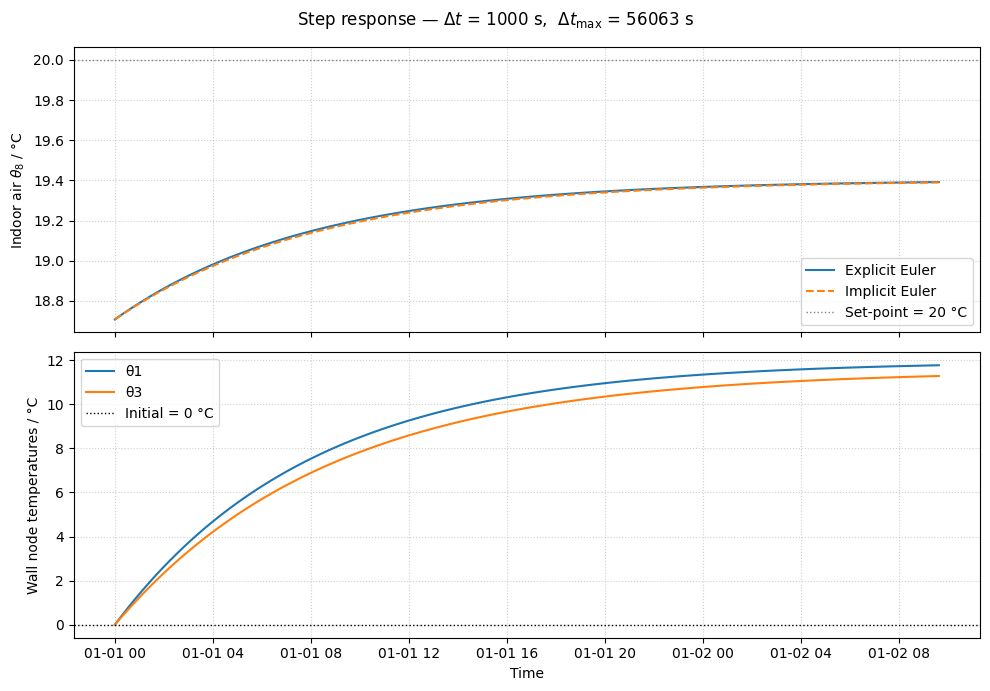

In [128]:
# ── Build time vector and constant input data ─────────────────────────────
n = int(np.floor(duration / dt))

time = pd.date_range(start="2000-01-01 00:00:00",
                     periods=n, freq=f"{int(dt)}s")

To_vec    = 0.0  * np.ones(n)   # °C, cold outdoor
Ti_sp_vec = 20.0 * np.ones(n)   # °C, HVAC setpoint
Φa_vec    = 0.0  * np.ones(n)
Qa_vec = Φo_vec = Φi_vec = Φa_vec

input_data_set = pd.DataFrame(
    {'To': To_vec, 'Ti_sp': Ti_sp_vec,
     'Φo': Φo_vec, 'Φi': Φi_vec, 'Qa': Qa_vec, 'Φa': Φa_vec},
    index=time
)

u = dm4bem.inputs_in_time(us, input_data_set)

print(f"Number of time steps : {n}")
print(f"Time step            : {dt:.0f} s")
print(f"Total duration       : {duration/3600:.1f} h")

# ── Initial conditions ────────────────────────────────────────────────────
θ0_init = 0  # °C — wall nodes start cold, far from setpoint

θ_exp = pd.DataFrame(index=u.index)
θ_imp = pd.DataFrame(index=u.index)

θ_exp[As.columns] = float(θ0_init)
θ_imp[As.columns] = float(θ0_init)

# ── Time integration loop ─────────────────────────────────────────────────
I = np.eye(As.shape[0])
A_exp = I + dt * As
A_imp = np.linalg.inv(I - dt * As)

for k in range(u.shape[0] - 1):
    θ_exp.iloc[k + 1] = A_exp @ θ_exp.iloc[k] + dt * Bs @ u.iloc[k]
    θ_imp.iloc[k + 1] = A_imp @ (θ_imp.iloc[k] + dt * Bs @ u.iloc[k])

# ── Outputs ───────────────────────────────────────────────────────────────
y_exp = (Cs @ θ_exp.T + Ds @ u.T).T
y_imp = (Cs @ θ_imp.T + Ds @ u.T).T

y_plot = pd.concat([y_exp, y_imp], axis=1, keys=['Explicit', 'Implicit'])
y_plot.columns = y_plot.columns.get_level_values(0)

print(f"\nInitial wall temperature   : θ₀ = {θ0_init} °C")
print(f"Explicit — final θ₈        : {float(y_exp.iloc[-1].iloc[0]):.2f} °C")
print(f"Implicit — final θ₈        : {float(y_imp.iloc[-1].iloc[0]):.2f} °C")
print(f"Difference at steady state : {abs(float(y_exp.iloc[-1].iloc[0]) - float(y_imp.iloc[-1].iloc[0])):.2e} °C")

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# ── Top: indoor air (output) ──────────────────────────────────────────────
axes[0].plot(y_plot.index, y_plot['Explicit'], label='Explicit Euler',
             color='tab:blue', linewidth=1.5)
axes[0].plot(y_plot.index, y_plot['Implicit'], label='Implicit Euler',
             color='tab:orange', linestyle='--', linewidth=1.5)
axes[0].axhline(Ti_sp_vec[0], color='gray', linestyle=':', linewidth=1,
                label=f'Set-point = {Ti_sp_vec[0]:.0f} °C')
axes[0].set_ylabel('Indoor air $\\theta_8$ / °C')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

# ── Bottom: wall state nodes (where the transient actually lives) ─────────
for col in θ_imp.columns:
    axes[1].plot(θ_imp.index, θ_imp[col], label=col, linewidth=1.5)
axes[1].axhline(θ0_init, color='black', linestyle=':', linewidth=1,
                label=f'Initial = {θ0_init} °C')
axes[1].set_ylabel('Wall node temperatures / °C')
axes[1].set_xlabel('Time')
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.6)

fig.suptitle(
    f'Step response — $\\Delta t$ = {dt:.0f} s,  '
    f'$\\Delta t_{{\\max}}$ = {Δtmax:.0f} s'
)
plt.tight_layout()
plt.show()

Figure 4: Step response to constant weather data listed in Table 19

The step response shows the building heating from a cold start (walls at 0 °C) toward steady state. The indoor air θ8 rises to 19.4 °C where is stabilizes after around 30 hours, slightly below the 20 °C setpoint due to the finite proportional controller gain $K_p$. The wall nodes stabilize at about 12 °C. Explicit and implicit Euler are virtually identical, confirming the imposed time step $\Delta t = 1000$ s is well within the stability limit.

## 10. Simulation with real weather data inputs

The inputs to the simulation are modelled by temperature and flow-rate sources.

- A temperature source has a temperature that is independent of the heat flow through it (e.g. outdoor air $T_o$, HVAC setpoint $T_{sp}$).
- A flow-rate source has a heat flow independent of temperature differences (e.g. solar radiation, internal gains).

For a dynamic simulation with real weather, the input data set $u_{set}$ contains time series for all six sources:

$$u_{set} = \begin{bmatrix} T_o \\ T_{i,sp} \\ \Phi_o \\ \Phi_i \\ Q_a \\ \Phi_a \end{bmatrix}$$

where:
- $T_o$ - outdoor air temperature [°C], from weather file
- $T_{i,sp}$ - indoor setpoint temperature [°C], from schedule
- $\Phi_o$ - solar radiation absorbed by the **outer** surfaces of the opaque envelope [W]
- $\Phi_i$ - solar radiation absorbed by the **inner** surfaces [W]
- $Q_a$ - auxiliary heat gains: occupants, equipment [W]
- $\Phi_a$ - solar radiation absorbed by the **glass** [W]

In [129]:
# ── Simulation period ─────────────────────────────────────────────────────
# Format: 'MM-DD HH:MM:SS'  — year 2000 is used by convention for TMY data
start_date = '2000-01-01 00:00:00'
end_date   = '2000-12-31 23:00:00'

print(f'Simulation start : {start_date}')
print(f'Simulation end   : {end_date}')

Simulation start : 2000-01-01 00:00:00
Simulation end   : 2000-12-31 23:00:00


### 10.1 Weather Data

Weather data is read from an [EnergyPlus Weather (EPW)](https://energyplus.net/weather-location/europe_wmo_region_6/FRA/FRA_Lyon.074810_IWEC) file for Lyon, FR. From the file we extract:

- `temp_air` - dry-bulb outdoor air temperature [°C]
- `dir_n_rad` - direct normal irradiance (beam radiation) [W/m²]
- `dif_h_rad` - diffuse horizontal irradiance [W/m²]

In [130]:
# ── Read EPW weather file ─────────────────────────────────────────────────
epw_filename = 'FRA_Lyon.074810_IWEC.epw'

[data, meta] = dm4bem.read_epw(epw_filename, coerce_year=None)
weather = data[['temp_air', 'dir_n_rad', 'dif_h_rad']]
del data

# Set year to 2000 by convention (TMY data has no fixed year)
weather.index = weather.index.map(lambda t: t.replace(year=2000))
weather = weather.loc[start_date:end_date]

print(f'Weather data loaded: {len(weather)} hourly rows')
print(f'Columns: {list(weather.columns)}')
print(weather.describe().round(1))

Weather data loaded: 8760 hourly rows
Columns: ['temp_air', 'dir_n_rad', 'dif_h_rad']
       temp_air  dir_n_rad  dif_h_rad
count  8760.000   8760.000   8760.000
mean     11.900     98.300     76.000
std       7.900    208.500    108.700
min      -8.500      0.000      0.000
25%       6.000      0.000      0.000
50%      11.600      0.000      4.000
75%      17.600     46.000    133.000
max      33.600    901.000    603.000


### 10.2 Solar Irradiance on Building Surfaces

The total solar irradiance on a tilted surface is computed using `dm4bem.sol_rad_tilt_surf()`, which decomposes the beam and diffuse radiation onto a plane defined by its `slope`, `azimuth`, and site `latitude`. The result is the sum of direct, diffuse, and ground-reflected components.

Our building has two distinct outdoor surfaces that receive solar radiation:

| Surface | Slope | Azimuth | Area |
|---|---|---|---|
| South window wall (glazing) | 90° (vertical) | 0° (south) | $S_w = 18\,\mathrm{m^2}$ |
| Ceiling (concrete, horizontal) | 0° | — | $S_{cl} = 24\,\mathrm{m^2}$ |

The three vertical concrete walls (N, E, W) are lumped. Since they face away from south, their direct solar gain is small compared to the glazing. For the outer surface solar load $\Phi_o$, the south-wall irradiance is used as a conservative upper estimate.

The ground reflectance (albedo) is set to 0.2, representative of an urban environment.

In [131]:
albedo = 0.2
latitude = 45.7640   # °, Lyon

# ── South-facing vertical wall (window + outer concrete walls) ────────────
surface_south = {'slope': 90, 'azimuth': 0, 'latitude': latitude}
rad_south = dm4bem.sol_rad_tilt_surf(weather, surface_south, albedo)
E_south = rad_south.sum(axis=1)   # W/m², total irradiance on south vertical

# ── Horizontal surface (ceiling) ──────────────────────────────────────────
surface_horiz = {'slope': 0, 'azimuth': 0, 'latitude': latitude}
rad_horiz = dm4bem.sol_rad_tilt_surf(weather, surface_horiz, albedo)
E_horiz = rad_horiz.sum(axis=1)   # W/m², total irradiance on horizontal

print('South wall irradiance — monthly means [W/m²]:')
print(E_south.resample('ME').mean().round(1).to_string())
print('\nHorizontal irradiance — monthly means [W/m²]:')
print(E_horiz.resample('ME').mean().round(1).to_string())

South wall irradiance — monthly means [W/m²]:
2000-01-31 00:00:00+01:00    38.500
2000-02-29 00:00:00+01:00    89.300
2000-03-31 00:00:00+01:00   124.900
2000-04-30 00:00:00+01:00   132.800
2000-05-31 00:00:00+01:00   133.100
2000-06-30 00:00:00+01:00   142.500
2000-07-31 00:00:00+01:00   150.900
2000-08-31 00:00:00+01:00   146.200
2000-09-30 00:00:00+01:00   135.800
2000-10-31 00:00:00+01:00    79.800
2000-11-30 00:00:00+01:00    47.800
2000-12-31 00:00:00+01:00    38.300
Freq: ME

Horizontal irradiance — monthly means [W/m²]:
2000-01-31 00:00:00+01:00    40.100
2000-02-29 00:00:00+01:00    80.100
2000-03-31 00:00:00+01:00   144.700
2000-04-30 00:00:00+01:00   186.100
2000-05-31 00:00:00+01:00   224.000
2000-06-30 00:00:00+01:00   261.700
2000-07-31 00:00:00+01:00   270.200
2000-08-31 00:00:00+01:00   225.000
2000-09-30 00:00:00+01:00   164.400
2000-10-31 00:00:00+01:00    86.500
2000-11-30 00:00:00+01:00    49.500
2000-12-31 00:00:00+01:00    35.000
Freq: ME


### 10.3 Flow-Rate Sources

The six flow-rate sources are computed from the irradiances as follows:

**Outer surface of concrete walls** - solar absorbed on the outdoor face:
$$\Phi_{o,walls} = \alpha_w \cdot E_{south} \cdot S_{cv}$$

**Outer surface of ceiling** - solar absorbed on the outdoor face:
$$\Phi_{o,ceil} = \alpha_w \cdot E_{horiz} \cdot S_{cl}$$

**Glass pane** - solar absorbed within the outer glass layer:
$$\Phi_a = \alpha_g \cdot E_{south} \cdot S_w$$

**Indoor air node** - solar transmitted through the double glazing plus internal gains:
$$Q_a = \tau_{dg} \cdot E_{south} \cdot S_w + Q_{int}$$

The inner surface of the opaque walls ($\Phi_i$) receives no direct solar radiation and is set to zero.

In [132]:
# ── Flow-rate sources ─────────────────────────────────────────────────────
Φo_walls = alpha_w * E_south * S_cv    # W, solar on outer concrete walls
Φo_ceil  = alpha_w * E_horiz * S_cl    # W, solar on outer ceiling
Φi       = 0 * E_south                 # W, inner walls — no direct solar
Φa       = alpha_g * E_south * S_w     # W, solar absorbed by outer glass
Qa       = tau_dg  * E_south * S_w + Q_int   # W, transmitted solar + gains

print('Peak flow-rate sources [W]:')
print(f'  Φo walls (max) : {Φo_walls.max():.1f}')
print(f'  Φo ceiling (max): {Φo_ceil.max():.1f}')
print(f'  Φa glass  (max) : {Φa.max():.1f}')
print(f'  Qa indoor (max) : {Qa.max():.1f}')

Peak flow-rate sources [W]:
  Φo walls (max) : 9907.1
  Φo ceiling (max): 6089.6
  Φa glass  (max) : 5647.1
  Qa indoor (max) : 1337.5


### 10.4 Schedules

**Indoor setpoint temperature** $T_{i,sp}$ - a day/night schedule is applied:
- Occupied hours (06:00–22:00): $T_{i,sp} = 20$ °C
- Unoccupied hours (22:00–06:00): $T_{i,sp} = 16$ °C 

**Auxiliary heat** $Q_{int}$ is already included in $Q_a$ above as a constant.

All the inputs used for this part of the simulation are plotted below.

In [133]:
# ── Indoor setpoint schedule ──────────────────────────────────────────────
Ti_day   = 20.0   # °C, occupied hours
Ti_night = 16.0   # °C, setback at night

Ti_sp = pd.Series(
    [Ti_day if 6 <= hour <= 22 else Ti_night
     for hour in weather.index.hour],
    index=weather.index
)

# ── Outdoor temperature ───────────────────────────────────────────────────
To = weather['temp_air']

# ── Assemble input data set ───────────────────────────────────────────────
# Column names must match the source labels in vectors b and f
input_data_set = pd.DataFrame({
    'To':   To,
    'Ti_sp': Ti_sp,
    'Φo':   Φo_walls,
    'Φi':   Φi,
    'Qa':   Qa,
    'Φa':   Φa
}, index=weather.index)

print('Input data set assembled:')
print(f'  Shape  : {input_data_set.shape}')
print(f'  Period : {input_data_set.index[0]}  →  {input_data_set.index[-1]}')
print('\nFirst 3 rows:')
print(input_data_set.head(3).round(2))

Input data set assembled:
  Shape  : (8760, 6)
  Period : 2000-01-01 00:00:00+01:00  →  2000-12-31 23:00:00+01:00

First 3 rows:
                              To  Ti_sp    Φo    Φi    Qa    Φa
2000-01-01 00:00:00+01:00  0.800 16.000 0.000 0.000 0.000 0.000
2000-01-01 01:00:00+01:00 -0.600 16.000 0.000 0.000 0.000 0.000
2000-01-01 02:00:00+01:00 -1.500 16.000 0.000 0.000 0.000 0.000


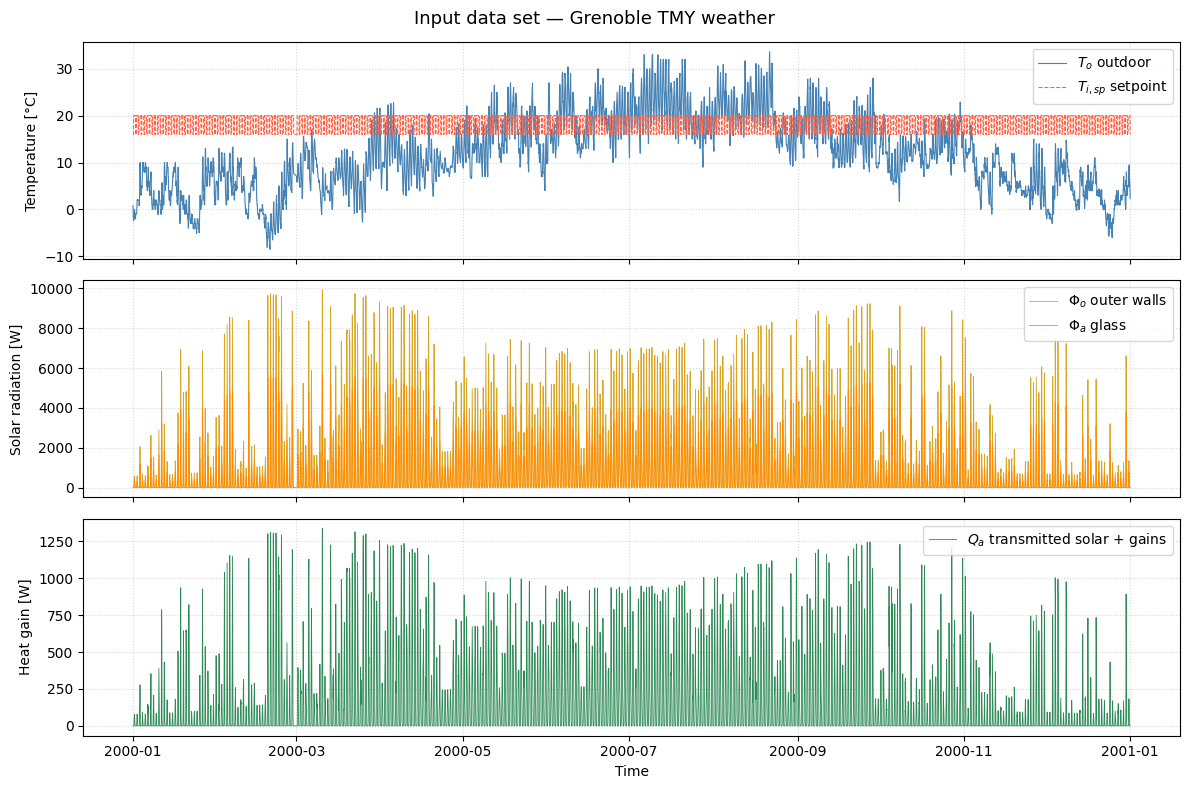

In [134]:
# ── Plot input data set ───────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Temperature sources
axes[0].plot(input_data_set.index, input_data_set['To'],
             label='$T_o$ outdoor', color='steelblue', linewidth=0.8)
axes[0].plot(input_data_set.index, input_data_set['Ti_sp'],
             label='$T_{i,sp}$ setpoint', color='tomato',
             linewidth=0.8, linestyle='--')
axes[0].set_ylabel('Temperature [°C]')
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle=':', alpha=0.5)

# Solar on envelope
axes[1].plot(input_data_set.index, input_data_set['Φo'],
             label='$\\Phi_o$ outer walls', color='goldenrod', linewidth=0.6)
axes[1].plot(input_data_set.index, input_data_set['Φa'],
             label='$\\Phi_a$ glass', color='darkorange', linewidth=0.6)
axes[1].set_ylabel('Solar radiation [W]')
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle=':', alpha=0.5)

# Indoor gains and transmitted solar
axes[2].plot(input_data_set.index, input_data_set['Qa'],
             label='$Q_a$ transmitted solar + gains', color='seagreen', linewidth=0.6)
axes[2].set_ylabel('Heat gain [W]')
axes[2].legend(loc='upper right')
axes[2].grid(True, linestyle=':', alpha=0.5)

axes[2].set_xlabel('Time')
fig.suptitle('Input data set — Grenoble TMY weather', fontsize=13)
plt.tight_layout()
plt.show()

Figure 5: Inputs (temperature, radiation, solar & internal gains) data sets

## 11. Dynamic Simulation: Real Weather

The state-space model is now integrated in time using the real weather inputs assembled in the previous section. The simulation follows three steps:

1. **Resample** the hourly weather data to the integration time step $\Delta t$ using linear interpolation.
2. **Integrate** the state-space model forward in time using implicit Euler.
3. **Recover the outputs** — indoor air temperature $\theta_8$ and HVAC thermal load $q_{12}$.

The implicit Euler scheme is used for the weather simulation since it is unconditionally stable and the time step is imposed at $\Delta t = 1000$ s, which is much larger than the explicit stability limit would allow with full capacities.

Input data resampled to dt = 1000 s
Total steps : 31619
Period      : 2000-01-01 00:00:00+01:00  →  2000-12-31 22:46:40+01:00

First 3 rows of input vector u:
                             q0    q3    q6   q11    q12    θ0    θ1    θ2  \
2000-01-01 00:00:00+01:00 0.800 0.800 0.800 0.800 16.000 0.000 0.000 0.000   
2000-01-01 00:16:40+01:00 0.620 0.620 0.620 0.620 16.000 0.000 0.000 0.000   
2000-01-01 00:33:20+01:00 0.440 0.440 0.440 0.440 16.000 0.000 0.000 0.000   

                             θ3    θ7    θ8  
2000-01-01 00:00:00+01:00 0.000 0.000 0.000  
2000-01-01 00:16:40+01:00 0.000 0.000 0.000  
2000-01-01 00:33:20+01:00 0.000 0.000 0.000  
Time integration complete.
State vector shape : (31619, 2)
Mean indoor temperature  : 18.72 °C
Min  indoor temperature  : 15.42 °C
Max  indoor temperature  : 20.56 °C
Peak heating load        : -7943.2 W
Peak cooling load        : 5641.6 W


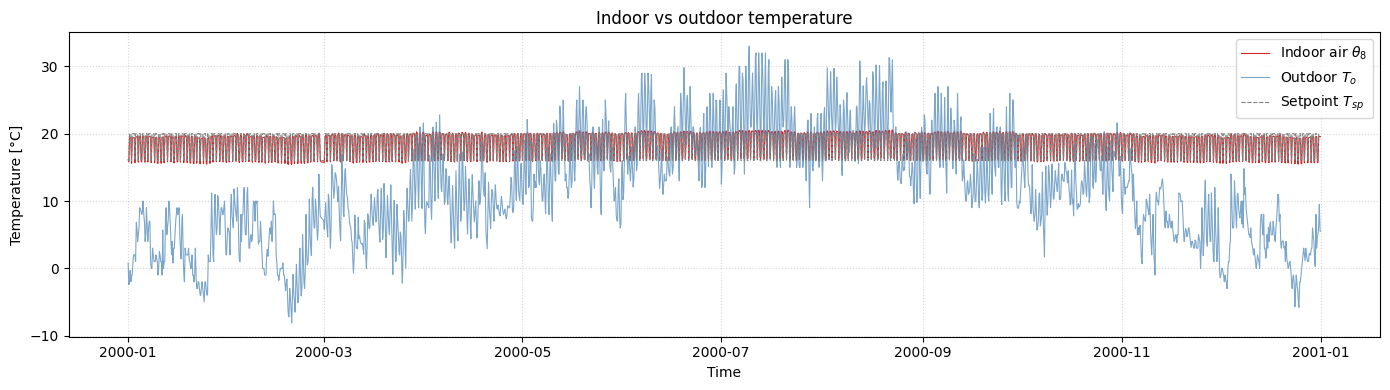

In [135]:
# ── Resample hourly weather data to simulation time step ──────────────────
input_data_set = input_data_set.resample(
    f'{int(dt)}s').interpolate(method='linear')

# ── Build input vector in time ────────────────────────────────────────────
u_weather = dm4bem.inputs_in_time(us, input_data_set)

print(f'Input data resampled to dt = {dt:.0f} s')
print(f'Total steps : {len(u_weather)}')
print(f'Period      : {u_weather.index[0]}  →  {u_weather.index[-1]}')
print('\nFirst 3 rows of input vector u:')
print(u_weather.head(3).round(2))

# ── Initial conditions ────────────────────────────────────────────────────
θ0_weather = 20.0   # °C, start walls at setpoint temperature

θ_w = pd.DataFrame(index=u_weather.index)
θ_w[As.columns] = float(θ0_weather)

# ── Time integration — implicit Euler only ────────────────────────────────
I     = np.eye(As.shape[0])
A_imp = np.linalg.inv(I - dt * As)

for k in range(u_weather.shape[0] - 1):
    θ_w.iloc[k + 1] = A_imp @ (θ_w.iloc[k] + dt * Bs @ u_weather.iloc[k])

print('Time integration complete.')
print(f'State vector shape : {θ_w.shape}')

# ── Indoor air temperature (output y = θ₈) ────────────────────────────────
y_weather = (Cs @ θ_w.T + Ds @ u_weather.T).T

# ── HVAC thermal load q₁₂ = Kp * (θ₈ - T_sp) ────────────────────────────
# q12 < 0 → heating;  q12 > 0 → cooling
θ8    = y_weather.iloc[:, 0]
Ti_sp_w = u_weather['q12'] if 'q12' in u_weather.columns \
          else input_data_set['Ti_sp'].reindex(u_weather.index, method='nearest')

Q_HVAC = Kp * (θ8 - input_data_set['Ti_sp'].reindex(
    θ8.index, method='nearest'))

print(f'Mean indoor temperature  : {θ8.mean():.2f} °C')
print(f'Min  indoor temperature  : {θ8.min():.2f} °C')
print(f'Max  indoor temperature  : {θ8.max():.2f} °C')
print(f'Peak heating load        : {Q_HVAC.min():.1f} W')
print(f'Peak cooling load        : {Q_HVAC.max():.1f} W')

# ── Plot 1: Temperatures ──────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(14, 4))

ax1.plot(θ8.index, θ8,
         color='tab:red', linewidth=0.8, label='Indoor air $\\theta_8$')
ax1.plot(input_data_set.index, input_data_set['To'],
         color='steelblue', linewidth=0.8, alpha=0.7, label='Outdoor $T_o$')
ax1.plot(input_data_set.index, input_data_set['Ti_sp'],
         color='gray', linewidth=0.8, linestyle='--', label='Setpoint $T_{sp}$')
ax1.set_ylabel('Temperature [°C]')
ax1.set_xlabel('Time')
ax1.set_title('Indoor vs outdoor temperature')
ax1.legend(loc='upper right')
ax1.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()




Figure 5: Indoor temperature vs outdoor temperature with perfect controller evolution

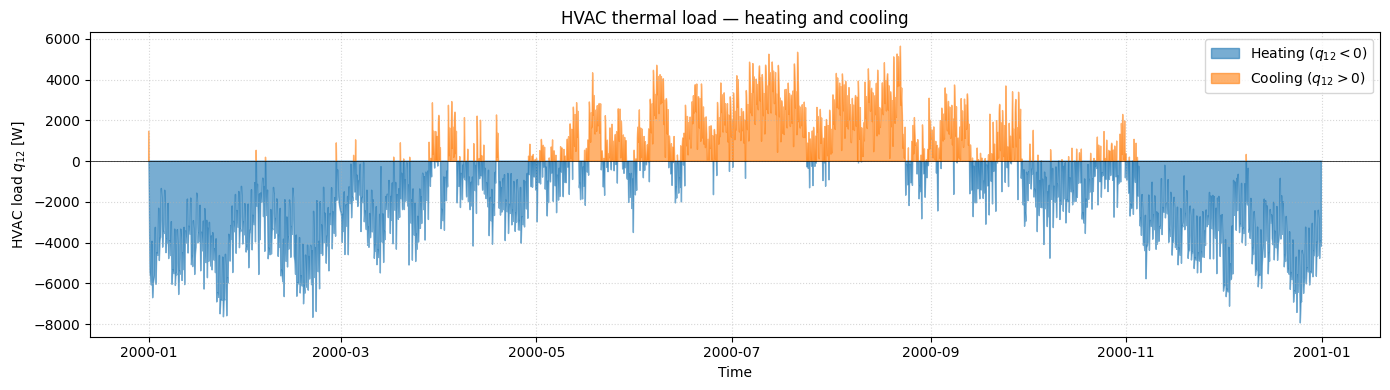

In [136]:
# ── Plot 2: HVAC Load ─────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(14, 4))

ax2.fill_between(Q_HVAC.index, Q_HVAC, 0,
                 where=(Q_HVAC < 0), color='tab:blue',
                 alpha=0.6, label='Heating ($q_{12} < 0$)')
ax2.fill_between(Q_HVAC.index, Q_HVAC, 0,
                 where=(Q_HVAC > 0), color='tab:orange',
                 alpha=0.6, label='Cooling ($q_{12} > 0$)')
ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_ylabel('HVAC load $q_{12}$ [W]')
ax2.set_xlabel('Time')
ax2.set_title('HVAC thermal load — heating and cooling')
ax2.legend(loc='upper right')
ax2.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()



Figure 6: HVAC heating vs cooling loads evolution

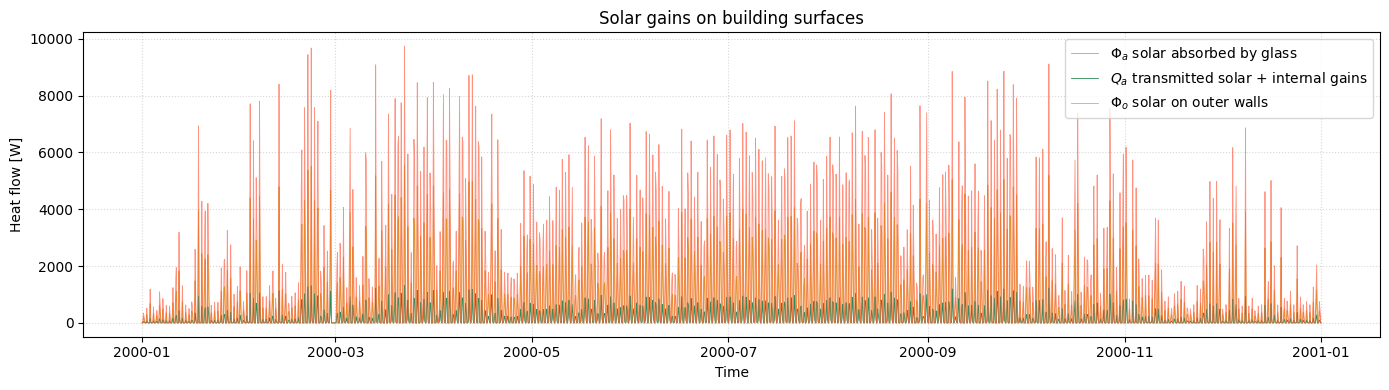

In [137]:
# ── Plot 3: Solar Gains ───────────────────────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(14, 4))

ax3.plot(input_data_set.index, input_data_set['Φa'],
         color='goldenrod', linewidth=0.6, label='$\\Phi_a$ solar absorbed by glass')
ax3.plot(input_data_set.index, input_data_set['Qa'],
         color='seagreen', linewidth=0.6, label='$Q_a$ transmitted solar + internal gains')
ax3.plot(input_data_set.index, input_data_set['Φo'],
         color='tomato', linewidth=0.6, alpha=0.7, label='$\\Phi_o$ solar on outer walls')
ax3.set_ylabel('Heat flow [W]')
ax3.set_xlabel('Time')
ax3.set_title('Solar gains on building surfaces')
ax3.legend(loc='upper right')
ax3.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

Figure 7: Solar and internal gains evolution

### Yearly energy consumption with real weather data

Unlike the steady-state yearly consumption calculated in previous sections, here we compute the energy directly from the dynamic simulation output $q_{12}(t)$, which already accounts for the thermal mass of the building, the day/night setback schedule, and the hour-by-hour variation of solar radiation and outdoor temperature.

The hourly energy is:

$$E_k = |q_{12,k}| \cdot \Delta t \quad \text{[J]}$$

converted to kWh by dividing by 3 600 000. Summing over all heating and cooling hours separately:

$$E_{heat} = \sum_{k:\, q_{12,k} < 0} |q_{12,k}| \cdot \frac{\Delta t}{3.6 \times 10^6} \quad \text{[kWh]}$$

$$E_{cool} = \sum_{k:\, q_{12,k} > 0} q_{12,k} \cdot \frac{\Delta t}{3.6 \times 10^6} \quad \text{[kWh]}$$

The monthly breakdown is obtained by resampling $q_{12}(t)$ to monthly sums.

The following was obtained as a result of the simulation:

Table 20: Yearly consumption from dynamic simulation

| Month | $E_{heat}$ [kWh] | $E_{cool}$ [kWh] |
|---|---|---|
| Jan | 3168.5 | 1.7 |
| Feb | 2563.3 | 2.2 |
| Mar | 1552.0 | 65.9 |
| Apr | 955.0 | 137.9 |
| May | 310.1 | 471.0 |
| Jun | 80.6 | 1127.4 |
| Jul | 17.3 | 1708.4 |
| Aug | 83.8 | 1537.8 |
| Sep | 260.4 | 682.0 |
| Oct | 798.0 | 82.8 |
| Nov | 2150.5 | 5.1 |
| Dec | 3125.8 | 0.3 |
| **TOTAL** | **15065.2** | **5822.5** |

Table 21: Summary of dynamic simulation result

| Metric | Value |
|---|---|
| Total heating energy | 15065 kWh/year |
| Total cooling energy | 5822 kWh/year |
| Total HVAC energy | 20888 kWh/year |
| Floor area | 24 m² |
| Specific consumption | 870.3 kWh/(m²·year) |

  Month   E_heat (kWh)   E_cool (kWh)
  ────────────────────────────────────
  Jan           3168.5            1.7
  Feb           2563.3            2.2
  Mar           1552.0           65.9
  Apr            955.0          137.9
  May            310.1          471.0
  Jun             80.6         1127.4
  Jul             17.3         1708.4
  Aug             83.8         1537.8
  Sep            260.4          682.0
  Oct            798.0           82.8
  Nov           2150.5            5.1
  Dec           3125.8            0.3
  ────────────────────────────────────
  TOTAL        15065.2         5822.5

  Total heating energy   :    15065 kWh/year
  Total cooling energy   :     5822 kWh/year
  Total HVAC energy      :    20888 kWh/year
  Specific consumption   :    870.3 kWh/(m²·year)


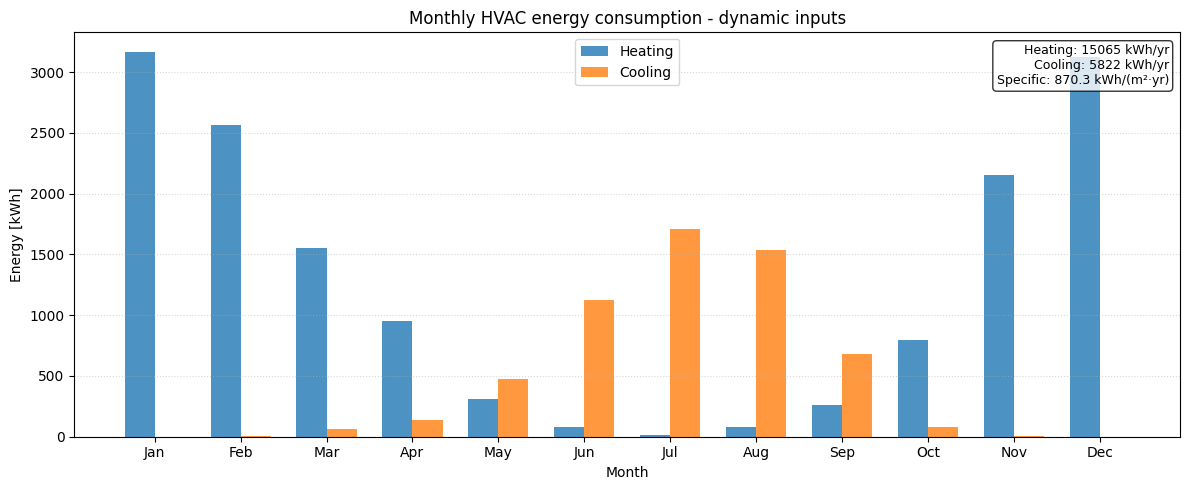

In [138]:
# ── Monthly energy from dynamic simulation ────────────────────────────────
Q_heat = Q_HVAC.copy()
Q_cool = Q_HVAC.copy()
Q_heat[Q_heat > 0] = 0    # keep only heating (negative values)
Q_cool[Q_cool < 0] = 0    # keep only cooling (positive values)

# Convert W → kWh  (dt in seconds, /3.6e6 to get kWh)
E_heat_dyn = (-Q_heat * dt / 3.6e6).resample('ME').sum()
E_cool_dyn = ( Q_cool * dt / 3.6e6).resample('ME').sum()

E_h_yr_dyn = E_heat_dyn.sum()
E_c_yr_dyn = E_cool_dyn.sum()
E_tot_dyn  = E_h_yr_dyn + E_c_yr_dyn

# ── Print monthly table ───────────────────────────────────────────────────
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

print(f"  {'Month':<5}  {'E_heat (kWh)':>13}  {'E_cool (kWh)':>13}")
print("  " + "─" * 36)
for i, (eh, ec) in enumerate(zip(E_heat_dyn, E_cool_dyn)):
    print(f"  {month_names[i]:<5}  {eh:>13.1f}  {ec:>13.1f}")
print("  " + "─" * 36)
print(f"  {'TOTAL':<5}  {E_h_yr_dyn:>13.1f}  {E_c_yr_dyn:>13.1f}")

print(f"\n  Total heating energy   : {E_h_yr_dyn:>8.0f} kWh/year")
print(f"  Total cooling energy   : {E_c_yr_dyn:>8.0f} kWh/year")
print(f"  Total HVAC energy      : {E_tot_dyn:>8.0f} kWh/year")
print(f"  Specific consumption   : {E_tot_dyn/S_fl:>8.1f} kWh/(m²·year)")

# ── Bar chart ─────────────────────────────────────────────────────────────
x = np.arange(12)
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, E_heat_dyn.values, width,
       label='Heating', color='tab:blue', alpha=0.8)
ax.bar(x + width/2, E_cool_dyn.values, width,
       label='Cooling', color='tab:orange', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(month_names)
ax.set_ylabel('Energy [kWh]')
ax.set_xlabel('Month')
ax.set_title('Monthly HVAC energy consumption - dynamic inputs')
ax.legend()
ax.grid(True, linestyle=':', alpha=0.5, axis='y')

# Annotate totals
ax.text(0.99, 0.97,
        f'Heating: {E_h_yr_dyn:.0f} kWh/yr\n'
        f'Cooling: {E_c_yr_dyn:.0f} kWh/yr\n'
        f'Specific: {E_tot_dyn/S_fl:.1f} kWh/(m²·yr)',
        transform=ax.transAxes, fontsize=9,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

Figure 8: Monthly energy consumption with dynamic inputs

### Discussion

**Indoor vs outdoor temperature**

The indoor air temperature $\theta_8$ remains nearly constant throughout the year, oscillating tightly between 16 °C (night setback) and 20 °C (occupied setpoint) thanks to the "perfect" proportional controller. The outdoor temperature varies widely from below −5 °C in winter to above 30 °C in summer yet the HVAC system successfully decouples the indoor climate from these swings.

**HVAC thermal load**

The seasonal pattern is clearly visible. Heating (blue, $q_{12} < 0$) dominates from October through March, with peak loads reaching around −7000 W on the coldest nights. Cooling (orange, $q_{12} > 0$) appears from April through September, peaking near +5000 W during the hottest summer days. The transition months (April - May and September - October) show a mix of both, reflecting days where solar gains are sufficient to overheat the room during the day while heating is still needed at night. Notably the cooling load is also significant this is likely driven by the large window wall leading to substantial solar radiation directly into the space during summer.


**Monthly energy consumption**

The bar chart confirms the seasonal pattern seen in the HVAC load plot. Heating energy dominates the winter months, with January and December being the most demanding due to low outdoor temperatures and minimal solar gains. The heating demand tapers off through spring as outdoor temperatures rise and solar gains through the south-facing glazing increasingly offset heat losses.

Cooling energy appears from late spring through summer, peaking in July and August. This raises a possible a weakness in the design. The same glazing that reduces heating demand in winter becomes a liability in summer.

Compared to the steady-state yearly consumption calculated in section 7 (699 kWh/m²·year) raised by about 170 kWh/m²·year. The dynamic simulation gives a more realistic figure because it accounts for the thermal mass of the concrete walls and varying external parameters which are the system's inputs. The dynamic result is therefore expected to be lower than the steady-state estimate, which assumes constant worst-case conditions for each month.


---
*Stefanos Theodoros Aristodemou · Irene Benito Gómez · Alberto Navarro López · Pedro Guilherme Cerqueira Sampaio*  
*Final Report - Smart Cities: Building Modeling - May 2026*